Walton pipeline

In [2]:
# using the EPM code as starting point

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ==========================================================
# Automated EPM + Fiber Photometry pipeline
# Flexible to zone numbering & header differences
# ==========================================================

# ----------------------------------------------------------
# Main configuration
# ----------------------------------------------------------

main_dir = Path(".").resolve()
#timepoints = ["Preinduction", "W1", "W2", "W3"]
timepoints = ["Preinduction", "W1", "W2"]


# Nose-point zone substrings for 3CT (FLEXIBLE MATCHING)
nosepoint_substrings = [
    "Social_interaction",
    "Novel_interaction",
]

# Fixed colors keyed by inner substring
zone_colors = {
    "Social_interaction": "#377EB8",   # blue
    "Novel_interaction": "#E41A1C",  # red
}


video_fps = 50.0
fp_fps = 50.0

figures_main_dir = main_dir / "Figures"
figures_main_dir.mkdir(parents=True, exist_ok=True)

# ==========================================================
# Helper functions
# ==========================================================

def _mouse_genotype_tag(mouse_id: str):
    id_clean = mouse_id.strip()
    if id_clean in {"372", "376", "423", "398", "400", "459", "450", "584", "597"}:
        return "NE"
    if id_clean in {"374", "429", "461", "463", "402"}:
        return "WT"
    return None

# # with new mice
# def _mouse_genotype_tag(mouse_id: str):
#     id_clean = mouse_id.strip()
#     if id_clean in {"372", "376", "423", "398", "400", "459", }:
#         return "NE"
#     if id_clean in {"374", "429", "461", "463", "402"}:
#         return "WT"
#     return None

def _read_export_and_get_fp_and_mouse_id(xl_path: Path):
    df = pd.read_excel(xl_path, header=None)
    key_col = df.iloc[:, 0].astype(str).str.strip().str.lower()

    # FP file
    match_fp = df[key_col == "fp file"]
    if match_fp.empty:
        raise ValueError(f"'FP file' not found in {xl_path.name}")
    fp_id = str(df.iloc[match_fp.index[0], 1]).strip()

    # Mouse ID
    #match_id = df[key_col == "id"]
    match_id = df[key_col == "id"]
    if match_id.empty:
        raise ValueError(f"'ID' row not found in {xl_path.name}")
    mouse_id = str(df.iloc[match_id.index[0], 1]).strip()

    return fp_id, mouse_id

def _extract_condition(eth_path: Path) -> str:
    """
    Find the 'Condition' row in the metadata (top of the EthoVision file)
    and return its value (e.g. Hab, Social, Novel).
    """
    raw = pd.read_excel(eth_path, header=None, nrows=50, engine="openpyxl")
    for i in range(len(raw)):
        if str(raw.iloc[i, 0]).strip() == "Condition":
            cond = str(raw.iloc[i, 1]).strip()
            # Normalise a bit
            cond_norm = cond.capitalize()
            if cond_norm in {"Hab", "Social", "Novel"}:
                return cond_norm
            return cond
    return "Unknown"



def _find_fp_and_timestamp_files(fp_folder: Path, fp_id: str):
    fp_csv = None
    for p in fp_folder.glob("*.csv"):
        if fp_id.lower() in p.name.lower():
            #fp_csv = p
            fil = fp_id + '.csv'
            fp_csv = fp_folder / fil
            break
    if fp_csv is None:
        raise FileNotFoundError(f"No FP CSV found in {fp_folder}")

    ts_csv = None
    for p in fp_folder.glob("*.csv"):
        if "time" in p.name.lower() or "timestamp" in p.name.lower():
            #ts_csv = p
            import os
            directory, filename = os.path.split(p)

            # Remove leading "._" if present
            new_filename = filename.lstrip("._") if filename.startswith("._") else filename

            # Join back together
            new_path = os.path.join(directory, new_filename)
            
            ts_csv = new_path
            break
    if ts_csv is None:
        raise FileNotFoundError(f"No timestamp CSV found in {fp_folder}")

    return fp_csv, ts_csv


def _coerce_bool_col(series):
    if series.dtype == bool:
        return series
    if pd.api.types.is_numeric_dtype(series):
        return (series.astype(float) > 0).astype(bool)
    low = series.astype(str).str.strip().str.lower()
    return low.isin(["true", "1", "t", "yes", "y"])


def _get_video_window(ts: pd.DataFrame):
    """Robust detection of video ON/OFF timestamps."""
    # Time column
    tcol = next(c for c in ts.columns if "time" in c.lower())
    t = pd.to_numeric(ts[tcol], errors="coerce")

    # Digital channel
    scol = None
    for c in ts.columns:
        if "digital" in c.lower() or "state" in c.lower():
            scol = c
            break

    # No digital info → use full recording
    if scol is None:
        return float(t.iloc[0]), float(t.iloc[-1])

    state = _coerce_bool_col(ts[scol])

    # If no transitions → full interval
    if state.sum() == 0 or (~state).sum() == 0:
        return float(t.iloc[0]), float(t.iloc[-1])

    # Use first True and first False
    try:
        video_start = float(t[state].iloc[0])
        video_stop = float(t[~state].iloc[0])
        if video_stop > video_start:
            return video_start, video_stop
    except:
        pass

    # Fallback
    return float(t.iloc[0]), float(t.iloc[-1])


def _build_time_vector_from_fp(fp_df):
    if "SystemTimestamp" in fp_df.columns:
        ts = pd.to_numeric(fp_df["SystemTimestamp"], errors="coerce")
        if ts.notna().sum() > len(ts) * 0.8:
            return ts.to_numpy()
    return np.arange(len(fp_df)) / fp_fps


def _snap_down_index(t, target):
    return max(0, np.searchsorted(t, target, side="right") - 1)


def _trim_fp_to_window(fp_df, start, stop):
    tt = _build_time_vector_from_fp(fp_df)
    if len(tt) != len(fp_df):
        n = min(len(tt), len(fp_df))
        tt = tt[:n]
        fp_df = fp_df.iloc[:n]

    i0 = _snap_down_index(tt, start)
    i1 = _snap_down_index(tt, stop)
    out = fp_df.iloc[i0:i1+1].copy()
    out["Time_video"] = tt[i0:i1+1] - tt[i0]
    return out


def _detect_header_row(eth_path: Path):
    preview = pd.read_excel(eth_path, header=None, nrows=50)

    firstcell = str(preview.iloc[0, 0])
    if "number of header lines" in firstcell.lower():
        m = re.findall(r"\d+", firstcell)
        if m:
            return int(m[0])

    col0 = preview.iloc[:, 0].astype(str)
    hits = col0[col0.str.contains("Trial time", case=False, na=False)]
    if not hits.empty:
        return hits.index[0]

    raise ValueError(f"Cannot detect header row in {eth_path.name}")


def _load_ethovision_sheet_with_targets(eth_path: Path, video_fps: float):
    header_row = _detect_header_row(eth_path)
    eth = pd.read_excel(eth_path, header=header_row).dropna(axis=1, how="all")

    # Time_s
    tcol = next((c for c in eth.columns if "time" in c.lower()), None)
    if tcol:
        eth["Time_s"] = pd.to_numeric(eth[tcol], errors="coerce")
    else:
        eth["Time_s"] = np.arange(len(eth)) / video_fps

    # Flexible matching of nose-point zone columns
    matched_cols = []
    for sub in nosepoint_substrings:
        for col in eth.columns:
            if sub in str(col):
                matched_cols.append(col)
                break

    if not matched_cols:
        raise ValueError(f"No nose-point zones found in {eth_path.name}")

    return eth[["Time_s"] + matched_cols].copy(), matched_cols


def _ethogram_segments(eth, beh_cols):
    segments = []
    for beh in beh_cols:
        mask = eth[beh] == 1
        if mask.sum() == 0:
            continue
        diff = mask.astype(int).diff().fillna(0)
        starts = eth.loc[diff == 1, "Time_s"]
        ends = eth.loc[diff == -1, "Time_s"]

        if mask.iloc[0]:
            starts = pd.concat([pd.Series([eth["Time_s"].iloc[0]]), starts])
        if mask.iloc[-1]:
            ends = pd.concat([ends, pd.Series([eth["Time_s"].iloc[-1]])])

        for s, e in zip(starts, ends):
            segments.append(
                {"Behavior": beh, "Start_time_s": float(s), "End_time_s": float(e),
                 "Duration_s": float(e - s)}
            )
    return pd.DataFrame(segments)


def _guess_zone_color(colname):
    for sub, color in zone_colors.items():
        if sub in colname:
            return color
    return "black"


def _plot_trial(fp_trim, eth_timeline, beh_cols, out_png, title_prefix):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2, 2, 1]})

    chan = "G0" if "G0" in fp_trim.columns else next(
        c for c in fp_trim.columns
        if pd.api.types.is_numeric_dtype(fp_trim[c])
        and c not in {"LedState", "SystemTimestamp", "Time_video", "Timestamp"}
    )

    # LED 1 – isosbestic
    fp1 = fp_trim[fp_trim["LedState"] == 1]
    axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
    axes[0].set_title(f"{title_prefix}: LED 1 (isosbestic)")
    axes[0].grid(True)

    # LED 2 – GCaMP
    fp2 = fp_trim[fp_trim["LedState"] == 2]
    axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
    axes[1].set_title(f"{title_prefix}: LED 2 (GCaMP)")
    axes[1].grid(True)

    # Ethogram
    for i, beh in enumerate(beh_cols):
        color = _guess_zone_color(beh)
        subset = eth_timeline[eth_timeline["Behavior"] == beh]
        for _, row in subset.iterrows():
            axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"],
                         height=0.6, color=color)

    axes[2].set_yticks(range(len(beh_cols)))
    axes[2].set_yticklabels(beh_cols)
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Time in zone (nose-point)")

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)


def _extract_led_traces(fp_trim, chan):
    iso = fp_trim.loc[fp_trim["LedState"] == 1, ["Time_video", chan]].rename(
        columns={chan: f"{chan}_iso415"})
    gcamp = fp_trim.loc[fp_trim["LedState"] == 2, ["Time_video", chan]].rename(
        columns={chan: f"{chan}_gcamp470"})
    return iso.reset_index(drop=True), gcamp.reset_index(drop=True)

# ==========================================================
# Main loop with week/timepoint added
# ==========================================================

fp_traces = {}

for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")
    tp_dir = main_dir / tp
    export_dir = tp_dir / "Export files"

    fig_dir_tp = figures_main_dir / tp
    fig_dir_raw = fig_dir_tp / "Raw_traces_ethograms"
    fig_dir_raw.mkdir(parents=True, exist_ok=True)

    trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
    if not trial_files:
        print(f"[WARN] No Raw data-*.xlsx files in {export_dir}")
        continue

    for eth_path in trial_files:
        try:
            # Condition (Hab / Social / Novel)
            condition = _extract_condition(eth_path)
            fp_id, mouse_id = _read_export_and_get_fp_and_mouse_id(eth_path)
            geno = _mouse_genotype_tag(mouse_id)

            fp_folder = tp_dir / fp_id
            fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)

            # Load FP
            fp = pd.read_csv(fp_csv, encoding="utf-8")
            fp = fp[fp["LedState"].isin([1, 2])]

            # Align timestamps
            ts = pd.read_csv(ts_csv, encoding="utf-8")
            video_start, video_stop = _get_video_window(ts)
            fp_trim = _trim_fp_to_window(fp, video_start, video_stop)

            # Detect channel
            chan = "G0" if "G0" in fp_trim.columns else next(
                c for c in fp_trim.columns
                if pd.api.types.is_numeric_dtype(fp_trim[c])
                and c not in {"LedState", "SystemTimestamp", "Time_video", "Timestamp"}
            )

            iso_df, gcamp_df = _extract_led_traces(fp_trim, chan)

            trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
            mouse_label = f"ID{mouse_id}" + (f"_{geno}" if geno else "")
            file_stub = f"{mouse_label}__{fp_id}__{trial_stub}"

            # Load EthoVision
            eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, video_fps)
            timeline = _ethogram_segments(eth, matched_cols)

            # Store all info in fp_traces, now including the 'week' field
            fp_traces[f"{tp}__{file_stub}"] = {
                "iso": iso_df,
                "gcamp": gcamp_df,
                "mouse_id": mouse_id,
                "genotype": geno,
                "timeline": timeline,
                "beh_cols": matched_cols,
                "condition": condition,
                "week": tp  # <--- NEW: store the timepoint/week
            }

            # Figure directory: by week and condition
            fig_dir_tp_cond = figures_main_dir / tp / condition / "Raw_traces_ethograms"
            fig_dir_tp_cond.mkdir(parents=True, exist_ok=True)

            # Plot trial
            out_png = fig_dir_tp_cond / f"{file_stub}_zones.png"
            _plot_trial(fp_trim, timeline, matched_cols, out_png,
                        title_prefix=f"{mouse_label} | {fp_id} | {trial_stub}")

            print(f"✔ {eth_path.name} → {out_png.name}")

        except Exception as e:
            print(f"[WARN] [{tp}] {eth_path.name}: {e}")



=== Processing timepoint: Preinduction ===
✔ Raw data-3CT_Preinduction-Trial     3.xlsx → ID376_NE__3CT_FP1_1__3CT_Preinduction-Trial_____3_zones.png
✔ Raw data-3CT_Preinduction-Trial     4.xlsx → ID376_NE__3CT_FP2_1__3CT_Preinduction-Trial_____4_zones.png
✔ Raw data-3CT_Preinduction-Trial     8.xlsx → ID372_NE__3CT_FP_2_1__3CT_Preinduction-Trial_____8_zones.png
✔ Raw data-3CT_Preinduction-Trial     9.xlsx → ID372_NE__3CT_FP_3_1__3CT_Preinduction-Trial_____9_zones.png
✔ Raw data-3CT_Preinduction-Trial    11.xlsx → ID374_WT__3CT_FP_5_1__3CT_Preinduction-Trial____11_zones.png
✔ Raw data-3CT_Preinduction-Trial    12.xlsx → ID374_WT__3CT_FP_6_1__3CT_Preinduction-Trial____12_zones.png
✔ Raw data-3CT_Preinduction-Trial    14.xlsx → ID429_WT__3CT_FP_8_1__3CT_Preinduction-Trial____14_zones.png
✔ Raw data-3CT_Preinduction-Trial    15.xlsx → ID429_WT__3CT_FP_9_1__3CT_Preinduction-Trial____15_zones.png
✔ Raw data-3CT_Preinduction-Trial    17.xlsx → ID423_NE__3CT_FP_11_1__3CT_Preinduction-Trial__

In [3]:
timeline = _ethogram_segments(eth, matched_cols)
timeline


,Behavior,Start_time_s,End_time_s,Duration_s
0,Social_interaction,27.72,28.66,0.94
1,Social_interaction,123.84,125.50,1.66
2,Social_interaction,128.10,135.46,7.36
3,Social_interaction,138.42,145.98,7.56
4,Social_interaction,147.22,148.92,1.70
5,Social_interaction,149.44,150.30,0.86
6,Social_interaction,152.52,155.92,3.40
7,Social_interaction,157.92,158.60,0.68
8,Social_interaction,161.02,162.36,1.34
9,Novel_interaction,91.88,93.06,1.18


In [4]:
list(fp_traces.keys())[:3]
first_key = next(iter(fp_traces))
fp_traces[first_key]


{'iso':       Time_video  G0_iso415
 0        0.00000   0.030769
 1        0.04000   0.030732
 2        0.08000   0.030762
 3        0.12000   0.030823
 4        0.16000   0.030758
 ...          ...        ...
 7493   299.71984   0.030588
 7494   299.75984   0.030669
 7495   299.79984   0.030609
 7496   299.83984   0.030635
 7497   299.87984   0.030661
 
 [7498 rows x 2 columns],
 'gcamp':       Time_video  G0_gcamp470
 0        0.02000     0.030832
 1        0.06000     0.030715
 2        0.10000     0.030729
 3        0.14000     0.030749
 4        0.18000     0.030819
 ...          ...          ...
 7493   299.73984     0.030835
 7494   299.77984     0.030739
 7495   299.81984     0.030792
 7496   299.85984     0.030808
 7497   299.89984     0.030813
 
 [7498 rows x 2 columns],
 'mouse_id': '376',
 'genotype': 'NE',
 'timeline':               Behavior  Start_time_s  End_time_s  Duration_s
 0   Social_interaction         15.54       31.10       15.56
 1   Social_interaction         3

In [5]:
import pandas as pd

fp_traces_df = pd.DataFrame.from_dict(fp_traces, orient="index")
fp_traces_df.head()


,iso,gcamp,mouse_id,genotype,timeline,beh_cols,condition,week
Preinduction__ID376_NE__3CT_FP1_1__3CT_Preinduction-Trial_____3,Time_video G0_iso415 0 0.00000 ...,Time_video G0_gcamp470 0 0.02000...,376,NE,Behavior Start_time_s End_time...,"[Social_interaction, Novel_interaction]",Social,Preinduction
Preinduction__ID376_NE__3CT_FP2_1__3CT_Preinduction-Trial_____4,Time_video G0_iso415 0 0.020000 ...,Time_video G0_gcamp470 0 0.000000...,376,NE,Behavior Start_time_s End_time...,"[Social_interaction, Novel_interaction]",Novel,Preinduction
Preinduction__ID372_NE__3CT_FP_2_1__3CT_Preinduction-Trial_____8,Time_video G0_iso415 0 0.020000 ...,Time_video G0_gcamp470 0 0.000000...,372,NE,Behavior Start_time_s End_time_...,"[Social_interaction, Novel_interaction]",Social,Preinduction
Preinduction__ID372_NE__3CT_FP_3_1__3CT_Preinduction-Trial_____9,Time_video G0_iso415 0 0.02000 ...,Time_video G0_gcamp470 0 0.00000...,372,NE,Behavior Start_time_s End_time...,"[Social_interaction, Novel_interaction]",Novel,Preinduction
Preinduction__ID374_WT__3CT_FP_5_1__3CT_Preinduction-Trial____11,Time_video G0_iso415 0 0.00000 ...,Time_video G0_gcamp470 0 0.02000...,374,WT,Behavior Start_time_s End_time...,"[Social_interaction, Novel_interaction]",Social,Preinduction


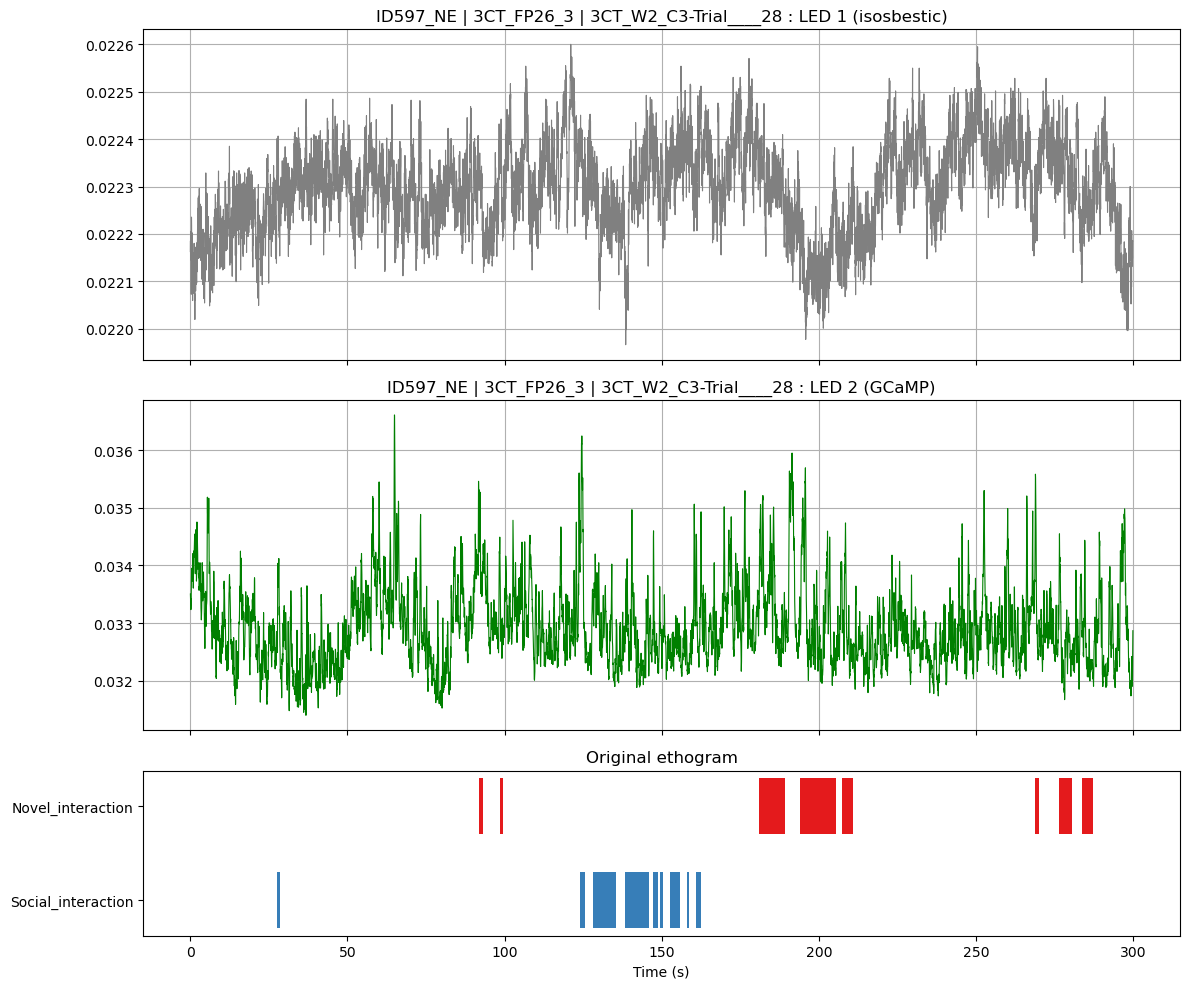

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- FP traces ---
chan = "G0" if "G0" in fp_trim.columns else next(
    c for c in fp_trim.columns
    if pd.api.types.is_numeric_dtype(fp_trim[c])
    and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
)

# LED 1
fp1 = fp_trim[fp_trim["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
axes[0].grid(True)

# LED 2
fp2 = fp_trim[fp_trim["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
axes[1].grid(True)

# 
## --- Original ethogram ---
# beh_cols_orig = timeline["Behavior"].unique()
# for i, beh in enumerate(beh_cols_orig):
#     color = _guess_zone_color(beh)
#     subset = timeline[timeline["Behavior"] == beh]
#     for _, row in subset.iterrows():
#         axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

# axes[2].set_yticks(range(len(beh_cols_orig)))
# axes[2].set_yticklabels(beh_cols_orig)

behaviors_in_timeline = timeline["Behavior"].unique()

for i, beh in enumerate(behaviors_in_timeline):
    color = _guess_zone_color(beh)
    subset = timeline[timeline["Behavior"] == beh]
    for _, row in subset.iterrows():
        axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"],
                     height=0.6, color=color)

axes[2].set_yticks(range(len(behaviors_in_timeline)))
axes[2].set_yticklabels(behaviors_in_timeline)


axes[2].invert_yaxis()
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Original ethogram")

axes[2].invert_yaxis()
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Original ethogram")

# --- Cleaned / collapsed ethogram ---
#beh_cols_clean = timeline_cleaned["Behavior"].unique()
#for i, beh in enumerate(beh_cols_clean):<
#    color = _guess_zone_color(beh)
#    subset = timeline_cleaned[timeline_cleaned["Behavior"] == beh]
#    for _, row in subset.iterrows():
#        axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)
#
#axes[3].set_yticks(range(len(beh_cols_clean)))
#axes[3].set_yticklabels(beh_cols_clean)
#axes[3].invert_yaxis()
#axes[3].set_xlabel("Time (s)")
#axes[3].set_title("Collapsed + cleaned ethogram")

plt.tight_layout()
plt.show()


In [7]:
#timeline_filter = timeline[timeline['Behavior']  != 'In zone 2(Arena / Nose-point)'].sort_values('Start_time_s')
timeline_filter = timeline[~timeline['Behavior'].str.contains('Arena / Nose-point')].sort_values('Start_time_s')

timeline_filter

,Behavior,Start_time_s,End_time_s,Duration_s
0,Social_interaction,27.72,28.66,0.94
9,Novel_interaction,91.88,93.06,1.18
10,Novel_interaction,98.56,99.54,0.98
1,Social_interaction,123.84,125.50,1.66
2,Social_interaction,128.10,135.46,7.36
3,Social_interaction,138.42,145.98,7.56
4,Social_interaction,147.22,148.92,1.70
5,Social_interaction,149.44,150.30,0.86
6,Social_interaction,152.52,155.92,3.40
7,Social_interaction,157.92,158.60,0.68


In [ ]:
import pandas as pd

def multi_zone_to_segments_fixed(eth, zone_keywords=None):
    """
    Converts multiple zone columns into a clean timeline of behavior segments.
    Any time not in a zone is labeled 'Other'.
    Preserves zone names as behaviors.

    Args:
        eth (pd.DataFrame): DataFrame with 'Time_s' and zone columns.
        zone_keywords (list, optional): Keywords to identify zone columns.
                                        Default matches 'Zone'.

    Returns:
        pd.DataFrame: Timeline with ['Behavior', 'Start_time_s', 'End_time_s', 'Duration_s']
    """
    if zone_keywords is None:
        zone_keywords = ["interaction"]

    # Find all zone columns
    zone_cols = [c for c in eth.columns if any(k in c for k in zone_keywords)]

    if not zone_cols:
        raise ValueError("No zone columns detected. Check your zone_keywords or column names.")

    # Melt to long format
    eth_long = eth.melt(id_vars="Time_s", value_vars=zone_cols,
                        var_name="Zone_col", value_name="Zone_active")

    # Ensure any active zone is marked; convert to boolean
    eth_long["Zone_active"] = eth_long["Zone_active"].fillna(0)
    eth_long["Zone_active"] = eth_long["Zone_active"].astype(bool)

    # Sort by time
    eth_long_sorted = eth_long.sort_values(["Time_s", "Zone_col"])

    timeline_rows = []
    last_behavior = None
    start_time = eth["Time_s"].iloc[0]

    # Iterate over time points
    for t, group in eth_long_sorted.groupby("Time_s"):
        active_zones = group.loc[group["Zone_active"], "Zone_col"].tolist()
        current_behavior = active_zones[0] if active_zones else "Other"

        if last_behavior is None:
            last_behavior = current_behavior
            start_time = t
        elif current_behavior != last_behavior:
            # Close previous segment
            timeline_rows.append({
                "Behavior": last_behavior,
                "Start_time_s": float(start_time),
                "End_time_s": float(t),
                "Duration_s": float(t - start_time)
            })
            last_behavior = current_behavior
            start_time = t

    # Add final segment
    timeline_rows.append({
        "Behavior": last_behavior,
        "Start_time_s": float(start_time),
        "End_time_s": float(eth["Time_s"].iloc[-1]),
        "Duration_s": float(eth["Time_s"].iloc[-1] - start_time)
    })

    return pd.DataFrame(timeline_rows)

# ------------------------
# Example usage
timeline = multi_zone_to_segments_fixed(eth)
timeline


In [ ]:
# Sanity check - number of entries into different zones using original ethogram
print("\nOriginal ethogram occurrences:")

# Get unique behaviors in the original timeline
behaviors_in_timeline = timeline["Behavior"].unique()

for beh in behaviors_in_timeline:
    subset = timeline[timeline["Behavior"] == beh]
    n_occurrences = len(subset)
    print(f"{beh}: {n_occurrences} instance(s)")

    # Optional: print detailed start/end/duration for each instance
    for idx, row in subset.iterrows():
        print(f"  Start: {row['Start_time_s']:.3f} s, "
              f"End: {row['End_time_s']:.3f} s, "
              f"Duration: {row['Duration_s']:.3f} s")

# generate the above plot for all trials


In [ ]:
import pandas as pd

# ---------------------------------------------------------
# Preprocessing: Fill gaps in timeline with "Other" (Arena removed)
# ---------------------------------------------------------
def fill_gaps_with_other(timeline_df, video_duration=300):
    """
    Converts a timeline DataFrame into a full timeline with gaps labeled as "Other",
    removes all 'Arena / Nose-point' behaviors, and ensures alternating segments
    covering the full video duration.

    Args:
        timeline_df (pd.DataFrame): Output from _ethogram_segments
                                     with columns ['Behavior', 'Start_time_s', 'End_time_s', 'Duration_s']
        video_duration (float): total duration of the video in seconds

    Returns:
        pd.DataFrame: Timeline with 'Other' segments filling any unassigned time,
                      Arena behaviors removed, and full coverage of video duration.
    """
    if timeline_df.empty:
        return pd.DataFrame([{
            "Behavior": "Other",
            "Start_time_s": 0.0,
            "End_time_s": video_duration,
            "Duration_s": video_duration
        }])

    # Remove Arena behaviors completely
    timeline_df = timeline_df[~timeline_df['Behavior'].str.contains('Arena / Nose-point', case=False)]

    timeline = []
    # Sort by start time
    timeline_df = timeline_df.sort_values('Start_time_s').reset_index(drop=True)

    last_end = 0.0

    for _, row in timeline_df.iterrows():
        start = float(row["Start_time_s"])
        end = float(row["End_time_s"])

        # Fill gap with Other if there is any
        if start > last_end:
            timeline.append({
                "Behavior": "Other",
                "Start_time_s": last_end,
                "End_time_s": start,
                "Duration_s": start - last_end
            })

        # Add current behavior
        timeline.append({
            "Behavior": row["Behavior"],
            "Start_time_s": start,
            "End_time_s": end,
            "Duration_s": end - start
        })

        last_end = end

    # Fill remaining time to end of video if necessary
    if last_end < video_duration:
        timeline.append({
            "Behavior": "Other",
            "Start_time_s": last_end,
            "End_time_s": video_duration,
            "Duration_s": video_duration - last_end
        })

    return pd.DataFrame(timeline).sort_values("Start_time_s").reset_index(drop=True)

for trial_key, trial_data in fp_traces.items():
    try:
        timeline = trial_data["timeline"]  # from _ethogram_segments
        timeline_full = fill_gaps_with_other(timeline, video_duration=300)
        trial_data["timeline_full"] = timeline_full
        trial_data["beh_cols_full"] = timeline_full["Behavior"].unique()
    except Exception as e:
        print(f"[WARN] Could not preprocess trial {trial_key}: {e}")

# Check first trial
first_trial_key = list(fp_traces.keys())[0]
print(fp_traces[first_trial_key]["timeline_full"].head(200))



In [ ]:
# Get first trial key
first_trial_key = list(fp_traces.keys())[0]
first_trial = fp_traces[first_trial_key]

# Access the full timeline with "Other"
timeline_full = first_trial["timeline_full"]

# Print the first 20 rows to check
print(timeline_full.head(200))


In [ ]:
# ==========================================================
# Plot original ethograms for all trials (no kernel smoothing)
# ==========================================================

for trial_key, trial_data in fp_traces.items():
    try:
        # --- Extract FP traces and original timeline ---
        iso_df = trial_data["iso"]
        gcamp_df = trial_data["gcamp"]
        timeline = trial_data["timeline"]  # Use original ethogram
        mouse_label = f"ID{trial_data['mouse_id']}" + (f"_{trial_data['genotype']}" if trial_data['genotype'] else "")
        fp_id = trial_key.split("__")[1]
        trial_stub = "__".join(trial_key.split("__")[2:])

        # --- Filter timeline (exclude Arena only if desired) ---
        timeline_filter = timeline[~timeline['Behavior'].str.contains('Arena / Nose-point', case=False)].sort_values('Start_time_s')

        # --- Setup 3-panel figure ---
        fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 2, 1]})

        # --- Panel 1: LED 1 (isosbestic) ---
        iso_col = [c for c in iso_df.columns if c != "Time_video"][0]
        axes[0].plot(iso_df["Time_video"], iso_df[iso_col], linewidth=0.8, color="gray")
        axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
        axes[0].grid(True)

        # --- Panel 2: LED 2 (GCaMP) ---
        gcamp_col = [c for c in gcamp_df.columns if c != "Time_video"][0]
        axes[1].plot(gcamp_df["Time_video"], gcamp_df[gcamp_col], linewidth=0.8, color="green")
        axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
        axes[1].grid(True)

        # --- Panel 3: Original ethogram ---
        beh_cols_orig = trial_data["beh_cols"]

        # Plot each behavior/zone
        for i, beh in enumerate(beh_cols_orig):
            color = _guess_zone_color(beh)
            subset = timeline_filter[timeline_filter["Behavior"] == beh]
            for _, row in subset.iterrows():
                axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        # Plot "Other" if present
        if "Other" in timeline_filter["Behavior"].values:
            i = len(beh_cols_orig)
            subset = timeline_filter[timeline_filter["Behavior"] == "Other"]
            for _, row in subset.iterrows():
                axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color="#CCCCCC")
            axes[2].set_yticks(range(len(beh_cols_orig)+1))
            axes[2].set_yticklabels(list(beh_cols_orig) + ["Other"])
        else:
            axes[2].set_yticks(range(len(beh_cols_orig)))
            axes[2].set_yticklabels(beh_cols_orig)

        axes[2].invert_yaxis()
        axes[2].set_xlabel("Time (s)")
        axes[2].set_title("Original ethogram")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"[WARN] Could not plot trial {trial_key}: {e}")

In [ ]:
for trial_key, trial_data in fp_traces.items():
    print(f"\nTrial: {trial_key}")
    if "timeline_kernel" not in trial_data:
        print("  No kernel-smoothed ethogram found.")
        continue

    tk = trial_data["timeline_kernel"]

    # Count number of separate occurrences for each behavior
    counts = tk["Behavior"].value_counts()
    for beh, n in counts.items():
        print(f"  {beh}: {n} instance(s)")


# code for manually subtracting iso from gcamp by aligning iso and gcamp to occur at same timepoints (a bit artificial, they do not occur at exactly the same timepoint)

In [ ]:
# ==========================================================
# Coregister ISO and GCaMP traces for all timepoints
# ==========================================================

import pandas as pd

def coregister_iso_gcamp(trial_traces: dict) -> pd.DataFrame:
    """
    trial_traces: dict with keys 'iso' and 'gcamp', each a DataFrame like:
        iso:   ['Time_video', 'G0_iso415']
        gcamp:['Time_video', 'G0_gcamp470']

    Returns one DataFrame with:
        Time_video  (from the channel that starts first)
        iso415
        gcamp470
    """
    iso = trial_traces["iso"].copy()
    gcamp = trial_traces["gcamp"].copy()

    # Get signal column names
    iso_col   = [c for c in iso.columns   if c != "Time_video"][0]
    gcamp_col = [c for c in gcamp.columns if c != "Time_video"][0]

    # Trim to common length just in case
    n = min(len(iso), len(gcamp))
    iso   = iso.iloc[:n].reset_index(drop=True)
    gcamp = gcamp.iloc[:n].reset_index(drop=True)

    # Decide which channel is "main" based on starting time
    if gcamp["Time_video"].iloc[0] <= iso["Time_video"].iloc[0]:
        # gcamp starts first → use its time
        time_main = gcamp["Time_video"].values
    else:
        # iso starts first → use its time
        time_main = iso["Time_video"].values

    aligned = pd.DataFrame({
        "Time_video": time_main,
        "iso415": iso[iso_col].values,
        "gcamp470": gcamp[gcamp_col].values,
    })

    return aligned

# -------------------------------------------------
# Apply coregistration to all trials in fp_traces
# -------------------------------------------------

coregistered_traces = {}  # store results per trial

for tp in timepoints:
    # Filter keys for this timepoint
    tp_keys = [k for k in fp_traces.keys() if k.startswith(f"{tp}__")]
    for k in tp_keys:
        try:
            aligned_df = coregister_iso_gcamp(fp_traces[k])
            coregistered_traces[k] = aligned_df
        except Exception as e:
            print(f"[WARN] Could not coregister {k}: {e}")

# Example access:


In [ ]:
# Show the first key
first_key = list(coregistered_traces.keys())[1]
print("First trial key:", first_key)

# Show the head of the aligned dataframe
print(coregistered_traces[first_key].head())


# Preprocessing

## Lowpass filtering to reduce noise.
https://github.com/ThomasAkam/photometry_preprocessing/blob/master/.ipynb_checkpoints/Photometry%20data%20preprocessing-checkpoint.ipynb



In [ ]:
import os
import numpy as  np
import pylab as plt
from scipy.signal import medfilt, butter, filtfilt
from scipy.stats import linregress
from scipy.optimize import curve_fit, minimize

#set default plot properties
plt.rcParams['figure.figsize'] = [14, 12] # Make default figure size larger.
plt.rcParams['axes.xmargin'] = 0          # Make default margin on x axis zero.
plt.rcParams['axes.labelsize'] = 12     #Set default axes label size 
plt.rcParams['axes.titlesize']=15
plt.rcParams['axes.titleweight']='heavy'
plt.rcParams['ytick.labelsize']= 10
plt.rcParams['xtick.labelsize']= 10
plt.rcParams['legend.fontsize']=12
plt.rcParams['legend.markerscale']=2

# Denoising

We lowpass filter the signals to reduce high frequency noise, using a zero phase filter with a 10Hz cutoff frequency.

In [ ]:

from scipy.signal import butter, filtfilt

sampling_rate = 50

# EXACT same filter design
b, a = butter(2, 10, btype='low', fs=sampling_rate)


for key, df in coregistered_traces.items():
    
    # Apply filtering EXACTLY like notebook
    df["gcamp_denoised"] = filtfilt(b, a, df["gcamp470"].values)
    df["iso_denoised"]   = filtfilt(b, a, df["iso415"].values)


trial_key = list(coregistered_traces.keys())[0]
df = coregistered_traces[trial_key]

fig, ax = plt.subplots(figsize=(10,5))

# Plot both signals on same axis
plot1 = ax.plot(df["Time_video"], df["gcamp_denoised"], 'g', label='gcamp denoised')
plot2 = ax.plot(df["Time_video"], df["iso_denoised"], 'r', label='iso denoised')

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Signal flourescence')
ax.set_title(f'Denoised signals — {trial_key}')

# Same legend logic
lines = plot1 + plot2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()

#check denoising added to original dataframe:
first_key = list(coregistered_traces.keys())[0]
print(coregistered_traces[first_key].columns)

## Photbleaching correction via double exponential fit (like neurophotometrics guide)
One way of removing the influence of bleaching is to fit an exponential decay to the data and subtract this exponential fit from the signal (note, some groups divide the signal by the baseline rather than subtracting the baseline, see Fiber Photometry Primer for more discussion). In practice we find that a double exponential fit is preferable to a single exponential fit because there are typically multiple sources of fluorescence that contribute to the bleaching (e.g. autofluorescence from fiber, autofluorescence from brain tissue, and flurophore fluorescence), which may bleach at different rates, so a single exponential fit can be overly restrictive.

First single trial to try out, then applied to all trials

In [ ]:
# ==========================================================
# Single trial: double exponential fit + bleach correction
# Both signals on the same Y-axis
# ==========================================================

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Pick the first trial
trial_key = list(coregistered_traces.keys())[0]
df = coregistered_traces[trial_key]

time_seconds = df["Time_video"].values

# ----------------------------------------------------------
# Double exponential function
# ----------------------------------------------------------
def double_exponential(t, const, amp_fast, amp_slow, tau_slow, tau_multiplier):
    """
    Compute a double exponential function with constant offset.
    Parameters
    ----------
    t           : array_like, time vector in seconds
    const       : amplitude of constant offset
    amp_fast    : amplitude of fast component
    amp_slow    : amplitude of slow component
    tau_slow    : time constant of slow component (s)
    tau_multiplier : time constant of fast component relative to slow
    """
    tau_fast = tau_slow * tau_multiplier
    return const + amp_slow * np.exp(-t / tau_slow) + amp_fast * np.exp(-t / tau_fast)

# ----------------------------------------------------------
# Fit double exponential to GCaMP
# ----------------------------------------------------------
max_sig = np.max(df["gcamp_denoised"])
initial_params = [max_sig/2, max_sig/4, max_sig/4, 3600, 0.1]
bounds = ([0, 0, 0, 600, 0],
          [max_sig, max_sig, max_sig, 36000, 1])

gcamp_params, _ = curve_fit(double_exponential, time_seconds, df["gcamp_denoised"],
                            p0=initial_params, bounds=bounds, maxfev=1000)
df["gcamp_expfit"] = double_exponential(time_seconds, *gcamp_params)

# ----------------------------------------------------------
# Fit double exponential to ISO
# ----------------------------------------------------------
max_sig = np.max(df["iso_denoised"])
initial_params = [max_sig/2, max_sig/4, max_sig/4, 3600, 0.1]
bounds = ([0, 0, 0, 600, 0],
          [max_sig, max_sig, max_sig, 36000, 1])

iso_params, _ = curve_fit(double_exponential, time_seconds, df["iso_denoised"],
                          p0=initial_params, bounds=bounds, maxfev=1000)
df["iso_expfit"] = double_exponential(time_seconds, *iso_params)

# ----------------------------------------------------------
# Bleach-corrected signals
# ----------------------------------------------------------
df["gcamp_bleach_corrected"] = df["gcamp_denoised"] - df["gcamp_expfit"]
df["iso_bleach_corrected"]   = df["iso_denoised"] - df["iso_expfit"]

# ==========================================================
# Plot 1: Denoised signals with double exponential fits
# Both on the same Y-axis
# ==========================================================
fig, ax1 = plt.subplots(figsize=(12,5))

# GCaMP
plot1 = ax1.plot(time_seconds, df["gcamp_denoised"], 'g', alpha=0.7, label='GCaMP denoised')
plot3 = ax1.plot(time_seconds, df["gcamp_expfit"], 'k', linewidth=1.5, label='GCaMP fit')

# ISO
plot2 = ax1.plot(time_seconds, df["iso_denoised"], 'r', alpha=0.7, label='ISO denoised')
plot4 = ax1.plot(time_seconds, df["iso_expfit"], 'k', linestyle='--', linewidth=1.5, label='ISO fit')

ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Signal (V)')
ax1.set_title('Denoised signals with double exponential fits (same Y-axis)')

# Legend
lines = plot1 + plot2 + plot3 + plot4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

# Dynamic Y-limits based on both signals
ymin = min(df["gcamp_denoised"].min(), df["iso_denoised"].min()) * 0.95
ymax = max(df["gcamp_denoised"].max(), df["iso_denoised"].max()) * 1.05
ax1.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

# ==========================================================
# Plot 2: Bleach-corrected (detrended) signals
# Both on the same Y-axis
# ==========================================================
fig, ax1 = plt.subplots(figsize=(12,5))

# GCaMP
plot1 = ax1.plot(time_seconds, df["gcamp_bleach_corrected"], 'g', alpha=0.7, label='GCaMP corrected')

# ISO
plot2 = ax1.plot(time_seconds, df["iso_bleach_corrected"], 'r', alpha=0.7, label='ISO corrected')

ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Bleach-corrected Signal (V)')
ax1.set_title('Bleaching Correction by Double Exponential Fit (same Y-axis)')

# Legend
lines = plot1 + plot2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

# Dynamic Y-limits based on both signals
ymin = min(df["gcamp_bleach_corrected"].min(), df["iso_bleach_corrected"].min()) * 1.05
ymax = max(df["gcamp_bleach_corrected"].max(), df["iso_bleach_corrected"].max()) * 1.05
ax1.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

In [ ]:


from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Double exponential function
# ----------------------------------------------------------
def double_exponential(t, const, amp_fast, amp_slow, tau_slow, tau_multiplier):
    """
    Compute a double exponential function with constant offset.
    Parameters
    ----------
    t           : array_like, time vector in seconds
    const       : amplitude of constant offset
    amp_fast    : amplitude of fast component
    amp_slow    : amplitude of slow component
    tau_slow    : time constant of slow component (s)
    tau_multiplier : time constant of fast component relative to slow
    """
    tau_fast = tau_slow * tau_multiplier
    return const + amp_slow * np.exp(-t / tau_slow) + amp_fast * np.exp(-t / tau_fast)

# Store fits and corrected signals
for trial_key, df in coregistered_traces.items():
    time_seconds = df["Time_video"].values

    # -------------------------
    # Fit GCaMP
    # -------------------------
    max_sig = np.max(df["gcamp_denoised"])
    initial_params = [max_sig/2, max_sig/4, max_sig/4, 3600, 0.1]
    bounds = ([0, 0, 0, 600, 0], [max_sig, max_sig, max_sig, 36000, 1])

    try:
        gcamp_params, _ = curve_fit(double_exponential, time_seconds, df["gcamp_denoised"],
                                    p0=initial_params, bounds=bounds, maxfev=1000)
        df["gcamp_expfit"] = double_exponential(time_seconds, *gcamp_params)
        df["gcamp_bleach_corrected"] = df["gcamp_denoised"] - df["gcamp_expfit"]
    except Exception as e:
        print(f"[WARN] Could not fit GCaMP for {trial_key}: {e}")
        df["gcamp_expfit"] = np.zeros_like(time_seconds)
        df["gcamp_bleach_corrected"] = df["gcamp_denoised"].copy()

    # -------------------------
    # Fit ISO
    # -------------------------
    max_sig = np.max(df["iso_denoised"])
    initial_params = [max_sig/2, max_sig/4, max_sig/4, 3600, 0.1]
    bounds = ([0, 0, 0, 600, 0], [max_sig, max_sig, max_sig, 36000, 1])

    try:
        iso_params, _ = curve_fit(double_exponential, time_seconds, df["iso_denoised"],
                                  p0=initial_params, bounds=bounds, maxfev=1000)
        df["iso_expfit"] = double_exponential(time_seconds, *iso_params)
        df["iso_bleach_corrected"] = df["iso_denoised"] - df["iso_expfit"]
    except Exception as e:
        print(f"[WARN] Could not fit ISO for {trial_key}: {e}")
        df["iso_expfit"] = np.zeros_like(time_seconds)
        df["iso_bleach_corrected"] = df["iso_denoised"].copy()

    # -------------------------
    # Plot: Denoised signals with exponential fits
    # -------------------------
    fig, ax1 = plt.subplots(figsize=(12,5))
    plot1 = ax1.plot(time_seconds, df["gcamp_denoised"], 'g', alpha=0.7, label='GCaMP denoised')
    plot3 = ax1.plot(time_seconds, df["gcamp_expfit"], 'k', linewidth=1.5, label='GCaMP fit')
    plot2 = ax1.plot(time_seconds, df["iso_denoised"], 'r', alpha=0.7, label='ISO denoised')
    plot4 = ax1.plot(time_seconds, df["iso_expfit"], 'k', linestyle='--', linewidth=1.5, label='ISO fit')

    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Signal')
    ax1.set_title(f'{trial_key}: Denoised signals with double exponential fits (same Y-axis)')

    lines = plot1 + plot2 + plot3 + plot4
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')

    ymin = min(df["gcamp_denoised"].min(), df["iso_denoised"].min()) * 0.95
    ymax = max(df["gcamp_denoised"].max(), df["iso_denoised"].max()) * 1.05
    ax1.set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.show()

    # -------------------------
    # Plot: Bleach-corrected signals
    # -------------------------
    fig, ax2 = plt.subplots(figsize=(12,5))
    plot1_corr = ax2.plot(time_seconds, df["gcamp_bleach_corrected"], 'g', alpha=0.7, label='GCaMP corrected')
    plot2_corr = ax2.plot(time_seconds, df["iso_bleach_corrected"], 'r', alpha=0.7, label='ISO corrected')

    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Signal')
    ax2.set_title(f'{trial_key}: Bleach-corrected signals (same Y-axis)')

    # Y-axis limits based on corrected signals
    ymin_corr = min(df["gcamp_bleach_corrected"].min(), df["iso_bleach_corrected"].min()) * 1.05
    ymax_corr = max(df["gcamp_bleach_corrected"].max(), df["iso_bleach_corrected"].max()) * 1.05
    ax2.set_ylim(ymin_corr, ymax_corr)

    lines_corr = plot1_corr + plot2_corr
    labels_corr = [l.get_label() for l in lines_corr]
    ax2.legend(lines_corr, labels_corr, loc='upper right')

    plt.tight_layout()
    plt.show()

#check columns added to overall dataframe
first_key = list(coregistered_traces.keys())[0]
print(coregistered_traces[first_key].columns)

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Double exponential
# ----------------------------------------------------------
def double_exponential(t, const, amp_fast, amp_slow, tau_slow, tau_multiplier):
    tau_fast = tau_slow * tau_multiplier
    return const + amp_slow * np.exp(-t / tau_slow) + amp_fast * np.exp(-t / tau_fast)

# ==========================================================
# Loop through trials
# ==========================================================
for trial_key, df in coregistered_traces.items():

    print(f"Processing {trial_key}")
    time_seconds = df["Time_video"].values

    # ======================================================
    # WALTON METHOD (old)
    # ======================================================
    # --- GCaMP fit ---
    max_g = np.max(df["gcamp_denoised"])
    p0 = [max_g/2, max_g/4, max_g/4, 3600, 0.1]
    bounds = ([0,0,0,600,0],[max_g,max_g,max_g,36000,1])

    gcamp_params, _ = curve_fit(double_exponential, time_seconds, df["gcamp_denoised"],
                                p0=p0, bounds=bounds, maxfev=5000)
    df["gcamp_expfit_walton"] = double_exponential(time_seconds, *gcamp_params)

    # --- ISO fit ---
    max_iso = np.max(df["iso_denoised"])
    p0_iso = [max_iso/2, max_iso/4, max_iso/4, 3600, 0.1]

    iso_params, _ = curve_fit(double_exponential, time_seconds, df["iso_denoised"],
                              p0=p0_iso, bounds=bounds, maxfev=5000)
    df["iso_expfit_walton"] = double_exponential(time_seconds, *iso_params)

    # --- Walton correction ---
    df["gcamp_corrected_walton"] = df["gcamp_denoised"] - df["gcamp_expfit_walton"]
    df["iso_corrected_walton"]   = df["iso_denoised"] - df["iso_expfit_walton"]

    # ======================================================
    # PHOTOMETRICS METHOD (new)
    # ======================================================
    # Reuse ISO fit
    df["iso_expfit_photometrics"] = df["iso_expfit_walton"]

    X = df["iso_expfit_photometrics"].values
    y = df["gcamp_denoised"].values

    m, b = np.polyfit(X, y, 1)
    df["gcamp_expfit_photometrics"] = m * X + b

    # --- Photometrics correction ---
    df["gcamp_corrected_photometrics"] = df["gcamp_denoised"] - df["gcamp_expfit_photometrics"] #use this!!
    df["iso_corrected_photometrics"]   = df["iso_denoised"] - df["iso_expfit_photometrics"]

    # ======================================================
    # PLOTTING
    # ======================================================
    plot_trials = True

    if plot_trials:

        # -------- Plot 1: RAW + FITS --------
        fig, ax = plt.subplots(figsize=(12,5))

        ax.plot(time_seconds, df["gcamp_denoised"], 'g', alpha=0.6, label='GCaMP raw')
        ax.plot(time_seconds, df["iso_denoised"], 'r', alpha=0.6, label='ISO raw')

        ax.plot(time_seconds, df["gcamp_expfit_walton"], 'k', label='GCaMP fit (Walton)')
        ax.plot(time_seconds, df["gcamp_expfit_photometrics"], 'k--', label='GCaMP fit (Photometrics)')

        ax.plot(time_seconds, df["iso_expfit_walton"], 'b--', label='ISO fit')

        ax.set_title(f"{trial_key} - Raw + Fits (Walton vs Photometrics)")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Signal")
        ax.legend()
        plt.tight_layout()
        plt.show()

        # -------- Plot 2: BLEACH CORRECTION --------
        fig, ax = plt.subplots(figsize=(12,5))

        ax.plot(time_seconds, df["gcamp_corrected_walton"], 'g', label='GCaMP (Walton)')
        ax.plot(time_seconds, df["gcamp_corrected_photometrics"], 'k', label='GCaMP (Photometrics)')

        ax.plot(time_seconds, df["iso_corrected_walton"], 'r', alpha=0.5, label='ISO corrected')

        ax.set_title(f"{trial_key} - Bleach Correction Comparison")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Corrected Signal")
        ax.legend()
        plt.tight_layout()
        plt.show()

## Motion correction

We now do motion correction by finding the best linear fit of the TdTomato signal to the dLight signal and subtracting this estimated motion component from the dLight signal. We will use the data that was bleaching corrected using the double exponential fit as this is less likely to remove meaningful slow variation in the signals.
first single trial

In [ ]:
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np

# Pick first trial
trial_key = list(coregistered_traces.keys())[0]
df = coregistered_traces[trial_key]

# Use bleach-corrected signals
#x = df["iso_bleach_corrected"].values       # TdTom / ISO
#y = df["gcamp_bleach_corrected"].values    # GCaMP

x = df["iso_corrected_photometrics"].values       # TdTom / ISO
y = df["gcamp_corrected_photometrics"].values    # GCaMP



# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Scatter plot (downsample every 5 points for clarity)
plt.figure(figsize=(6,6))
plt.scatter(x[::5], y[::5], alpha=0.1, marker='.', color='purple')

# Regression line
line_x = np.array(plt.xlim())
line_y = intercept + slope*line_x
plt.plot(line_x, line_y, color='black', linewidth=2)

plt.xlabel('TdTomato (bleach-corrected)')
plt.ylabel('GCaMP (bleach-corrected)')
plt.title(f'{trial_key}: TdTomato - GCaMP correlation')
plt.tight_layout()
plt.show()

# Print regression stats
print(f"Slope    : {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"p-value  : {p_value:.3e}")
print(f"Std err  : {std_err:.3f}")

In [ ]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt

# Dictionary to store motion-corrected traces
motion_corrected_traces = {}

# Loop over all trials
for trial_key, df in coregistered_traces.items():
    
    time_seconds = df["Time_video"].values
    
    # Bleach-corrected signals
    iso_detrended = df["iso_corrected_photometrics"].values      # TdTom / ISO
    gcamp_detrended = df["gcamp_corrected_photometrics"].values  # GCaMP / dLight


    # ---------------------------------------------------------
    # Linear regression: motion correction
    # ---------------------------------------------------------
    slope, intercept, r_value, p_value, std_err = linregress(iso_detrended, gcamp_detrended)

    # Estimate motion contribution
    gcamp_est_motion = intercept + slope * iso_detrended
    gcamp_motion_corrected = gcamp_detrended - gcamp_est_motion

    # Store results
    motion_corrected_traces[trial_key] = {
        "gcamp_motion_corrected": gcamp_motion_corrected,
        "gcamp_est_motion": gcamp_est_motion,
        "slope": slope,
        "intercept": intercept,
        "r_value": r_value,
        "p_value": p_value,
        "std_err": std_err,
        "time_seconds": time_seconds
    }

    # ---------------------------------------------------------
    # Plot motion correction
    # ---------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(12,5))
    
    # Pre-motion corrected
    plot1 = ax1.plot(time_seconds, gcamp_detrended, 'b', alpha=0.5, label='GCaMP - pre motion correction')
    
    # Motion-corrected
    plot3 = ax1.plot(time_seconds, gcamp_motion_corrected, 'g', alpha=0.5, label='GCaMP - motion corrected')
    
    # Shift motion trace for visual alignment
    motion_offset = gcamp_detrended.mean() - gcamp_motion_corrected.mean()
    plot4 = ax1.plot(time_seconds, gcamp_est_motion + motion_offset, 'y', label='Estimated motion (shifted)')
    
    # Auto Y-axis limits based on the range of signals
    combined = np.concatenate([gcamp_detrended, gcamp_motion_corrected, gcamp_est_motion + motion_offset])
    y_min, y_max = combined.min(), combined.max()
    y_padding = (y_max - y_min) * 0.05  # 5% padding
    ax1.set_ylim(y_min - y_padding, y_max + y_padding)
    
    # Add trial key at top
    ax1.set_title(f'Motion Correction: {trial_key}', fontsize=14, pad=15)
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('GCaMP Signal')
    
    # Combine legend
    lines = plot1 + plot3 + plot4
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(0.95, 0.98))
    
    # Optional zoom per trial
    # ax1.set_xlim(1000, 1060)
    
    plt.tight_layout()
    plt.show()
    
    # Print regression stats
    print(f"\nTrial: {trial_key}")
    print(f" Slope    : {slope:.3f}")
    print(f" Intercept: {intercept:.3f}")
    print(f" R-squared: {r_value**2:.3f}")
    print(f" p-value  : {p_value:.3e}")
    print(f" Std err  : {std_err:.3f}")

    #add the variables to the data frame
    df["gcamp_motion_corrected"] = gcamp_motion_corrected
    df["gcamp_est_motion"] = gcamp_est_motion

 #check columns added to overall dataframe
first_key = list(coregistered_traces.keys())[0]
print(coregistered_traces[first_key].columns)

## Normalisation

Typically in a photometry experiment we want to combine data across sessions and/or subjects. This is complicated by the fact that different sessions may have different levels of fluorphore expression, excitation light and autofluorescence. It is therefore desirable to normalise the data to reduce this variability. The two most widely used ways of doing this are computing dF/F or z-scores.

Method 1: dF/F

To compute dF/F we divide the signal changes (dF) by the baseline fluorescence (F) and multiply by 100 to convert to percent. The dF is just the motion corrected signal plotted above. The baseline fluorescence F changes over the course of the session due to photobleaching, and is just the baseline we estimated with our double exponential fit.
Question: if using the old exp fit from gcamp, wouldnt that one have a much higher number, and a curve?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a trial
trial_key = list(coregistered_traces.keys())[0]
df = coregistered_traces[trial_key]

time_seconds = df["Time_video"].values

# Compute ΔF/F (%) using motion-corrected signal and exponential fit - so it is not divided by the iso signal, but by the double exponential fit from earlier - however, that was fit before bleach correction, so why do we divide by this? wouldn't this have the bleaching slope with it, which our new trace does not? would it be better to divide by the bleach corrected iso signal? or even add motion correction to the iso signal and divide by the motion-corrected iso signal?
#gcamp_dF_F = 100 * df["gcamp_motion_corrected"] / df["gcamp_expfit"]
gcamp_dF_F = 100 * df["gcamp_motion_corrected"] / df["gcamp_expfit_photometrics"]

#
    # --- Photometrics correction ---


# Example reward cue times (replace with your actual reward timestamps if available)
# reward_cue_times = np.array([...])
# For now, we'll just leave this commented or empty if you don't have them
reward_cue_times = np.array([])  

# Plot ΔF/F
fig, ax1 = plt.subplots(figsize=(12,5))

plot1 = ax1.plot(time_seconds, gcamp_dF_F, 'g', label='GCaMP dF/F')
if reward_cue_times.size > 0:
    reward_ticks = ax1.plot(reward_cue_times, np.full(np.size(reward_cue_times), 6),
                            label='Reward Cue', color='w', marker="v", mfc='k', mec='k', ms=8)

ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('GCaMP dF/F (%)')
ax1.set_title(f'{trial_key}: GCaMP ΔF/F')

# Legend
lines = plot1
if reward_cue_times.size > 0:
    lines += reward_ticks
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(0.95, 0.98))


plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example reward cue times (replace with actual timestamps if available)
reward_cue_times = np.array([])

# Loop over all trials
for trial_key, df in coregistered_traces.items():
    time_seconds = df["Time_video"].values

    # Compute ΔF/F (%) for GCaMP (gcamp_bleach_corrected / gcamp_expfit)
    gcamp_dF_F = 100 * df["gcamp_motion_corrected"] / df["gcamp_expfit_photometrics"]
    df["gcamp_dF_F"] = 100 * df["gcamp_motion_corrected"] / df["gcamp_expfit_photometrics"]

    # Optional: compute ΔF/F for ISO channel if desired
    # df["iso_dF_F"] = 100 * df["iso_bleach_corrected"] / df["iso_expfit"]

    # -------------------------
    # Plot ΔF/F for each trial
    # -------------------------
    fig, ax1 = plt.subplots(figsize=(12,5))
    
    plot1 = ax1.plot(time_seconds, df["gcamp_dF_F"], 'g', label='GCaMP dF/F')
    
    if reward_cue_times.size > 0:
        reward_ticks = ax1.plot(reward_cue_times, np.full(np.size(reward_cue_times), 6),
                                label='Reward Cue', color='w', marker="v", mfc='k', mec='k', ms=8)
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('GCaMP dF/F (%)')
    ax1.set_title(f'{trial_key}: GCaMP ΔF/F')
    
    # Combine legend
    lines = plot1
    if reward_cue_times.size > 0:
        lines += reward_ticks
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(0.95, 0.98))
    
    
    plt.tight_layout()
    plt.show()
    #add the variables to the data frame
    #df["gcamp_motion_corrected"] = gcamp_motion_corrected
    #df["gcamp_est_motion"] = gcamp_est_motion


 #check columns added to overall dataframe
first_key = list(coregistered_traces.keys())[0]
print(coregistered_traces[first_key].columns)

Method 2: Z-scoring

Alternatively, we can normalise the data by z-scoring each session - i.e. subtracting the mean and dividing by the standard deviation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example reward cue times (replace with actual timestamps if available)
reward_cue_times = np.array([])

# Loop over all trials
for trial_key, df in coregistered_traces.items():
    time_seconds = df["Time_video"].values

    # Compute z-score for motion- and bleach-corrected GCaMP
    df["gcamp_z"] = (df["gcamp_motion_corrected"] - np.mean(df["gcamp_motion_corrected"])) / np.std(df["gcamp_motion_corrected"])

    # Optional: compute z-score for ISO if desired
    # df["iso_z"] = (df["iso_corrected"] - np.mean(df["iso_corrected"])) / np.std(df["iso_corrected"])

    # -------------------------
    # Plot z-scored GCaMP for each trial
    # -------------------------
    fig, ax1 = plt.subplots(figsize=(12,5))
    
    plot1 = ax1.plot(time_seconds, df["gcamp_z"], 'g', label='GCaMP z-score')
    
    
    if reward_cue_times.size > 0:
        reward_ticks = ax1.plot(reward_cue_times, np.full(np.size(reward_cue_times), 6),
                                label='Reward Cue', color='w', marker="v", mfc='k', mec='k', ms=8)
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('GCaMP z-score')
    ax1.set_title(f'{trial_key}: GCaMP z-scored')
    
    # Combine legend
    lines = plot1
    if reward_cue_times.size > 0:
        lines += reward_ticks
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(0.95, 0.98))
    
    
    plt.tight_layout()
    plt.show()

 #check columns added to overall dataframe
first_key = list(coregistered_traces.keys())[0]
print(coregistered_traces[first_key].columns)

# Putting together corrections to ethovision ethogram and FP preprocessed traces

below code uses all the preprocessed signals, also the intermediares + skip to the next block to see only delta F over F signal

In [ ]:
def map_ethogram_to_time_vector(time_vector, timeline_ethogram):
    """
    Assign behavior to each FP timepoint exactly as in the original ethogram.
    Fills any gaps with 'Other'.

    Args:
        time_vector (np.ndarray or pd.Series): Timepoints from FP recording.
        timeline_ethogram (pd.DataFrame): Original ethogram with columns
                                          ['Behavior', 'Start_time_s', 'End_time_s'].

    Returns:
        np.ndarray: Array of behaviors for each timepoint in `time_vector`.
    """
    behavior_at_time = np.array(["Other"] * len(time_vector), dtype=object)

    for _, row in timeline_ethogram.iterrows():
        mask = (time_vector >= row["Start_time_s"]) & (time_vector < row["End_time_s"])
        behavior_at_time[mask] = row["Behavior"]

    return behavior_at_time

In [ ]:

combined_trials = {}

for key in coregistered_traces.keys():
    df = coregistered_traces[key].copy()
    
    if "timeline" in fp_traces[key]:
        timeline_orig = fp_traces[key]["timeline"]
        
        df["Behavior"] = map_ethogram_to_time_vector(
            df["Time_video"].values,   # ← likely fix
            timeline_orig
        )
    else:
        df["Behavior"] = "Unknown"
    
    combined_trials[key] = df

In [ ]:
print(fp_traces[key].keys())

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_dff_with_ethogram(df, key, save_dir=None):
    """
    Plot only the dF/F (%) signal together with kernel-smoothed ethogram.

    df must contain:
        Time_video
        dFF
        Behavior
    """
    time = df["Time_video"].values
    dFF = df["gcamp_dF_F"].values
    behaviors = df["Behavior"].values

    # Unique behaviors and colors
    beh_labels = np.unique(behaviors)
    colors = plt.cm.tab10(np.arange(len(beh_labels)))  # up to 10 colors
    beh_color_map = dict(zip(beh_labels, colors))

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))

    # Plot dF/F
    ax.plot(time, dFF, color="purple", linewidth=1)
    ax.set_ylabel("dF/F (%)")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{key} — dF/F with kernel-smoothed ethogram")

    # Overlay ethogram as colored bands
    for beh in beh_labels:
        mask = behaviors == beh
        ax.fill_between(time, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=mask, color=beh_color_map[beh], alpha=0.2, step="post")

    # Legend for behaviors
    handles = [mpatches.Patch(color=beh_color_map[b], alpha=0.3, label=b) for b in beh_labels]
    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()

    if save_dir is not None:
        out = save_dir / f"{key}_dFF_ethogram.png"
        plt.savefig(out, dpi=200)
        plt.close()
    else:
        plt.show()


In [ ]:


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_zscore_with_ethogram(df, key, save_dir=None):
    """
    Plot only the dF/F (%) signal together with kernel-smoothed ethogram.

    df must contain:
        Time_video
        dFF
        Behavior
    """
    time = df["Time_video"].values
    zscore = df["gcamp_z"].values
    behaviors = df["Behavior"].values

    # Unique behaviors and colors
    beh_labels = np.unique(behaviors)
    colors = plt.cm.tab10(np.arange(len(beh_labels)))  # up to 10 colors
    beh_color_map = dict(zip(beh_labels, colors))

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))

    # Plot dF/F
    ax.plot(time, zscore, color="purple", linewidth=1)
    ax.set_ylabel("Z score")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{key} — Z scorewith ethogram")

    # Overlay ethogram as colored bands
    for beh in beh_labels:
        mask = behaviors == beh
        ax.fill_between(time, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=mask, color=beh_color_map[beh], alpha=0.2, step="post")

    # Legend for behaviors
    handles = [mpatches.Patch(color=beh_color_map[b], alpha=0.3, label=b) for b in beh_labels]
    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()

    if save_dir is not None:
        out = save_dir / f"{key}_dFF_ethogram.png"
        plt.savefig(out, dpi=200)
        plt.close()
    else:
        plt.show()


In [ ]:
example_key = list(combined_trials.keys())[0]
#plot_dff_with_ethogram(combined_trials[example_key], example_key)
plot_zscore_with_ethogram(combined_trials[example_key], example_key)


In [ ]:
plot_dff_with_ethogram(combined_trials[example_key], example_key)

In [ ]:
# Loop over all trials and display the dF/F plot with ethogram and legend
for example_key in combined_trials.keys():
    plot_dff_with_ethogram(combined_trials[example_key], example_key, save_dir=None)

# PERI EVENT PLOTS CORRECTED SIGNAL


In [ ]:
print(df.columns)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
pre_s = 2.0      # seconds before event
post_s = 4.0     # seconds after event
min_stay_s = 0   # optional, if you want to filter very short events

# Pick first trial
example_key = list(combined_trials.keys())[1]
#df = combined_trials[example_key].copy()

df = combined_trials[example_key].copy()

time_vec = df["Time_video"].values
#signal_vec = df["dFF"].values
signal_vec = df["gcamp_dF_F"].values
behaviors = df["Behavior"].values

# Unique behaviors
unique_beh = np.unique(behaviors)

# Loop over behaviors
for beh in unique_beh:
    # Find event starts (transition into this behavior)
    mask = (behaviors == beh)
    mask_int = mask.astype(int)  # convert bool to int
    diffs = np.diff(np.r_[0, mask_int])  # prepend 0 for first element
    event_starts_idx = np.where(diffs == 1)[0]  # rising edges

    # Skip if no eventsimport numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
pre_s = 2.0      # seconds before event
post_s = 4.0     # seconds after event
min_stay_s = 0   # optional: ignore very short events

# Pick first example trial
example_key = list(combined_trials.keys())[1]
df = combined_trials[example_key].copy()

# FP time and signal
time_vec = df["Time_video"].values
#signal_vec = df["dFF"].values
signal_vec = df["gcamp_dF_F"].values

# Behavior labels from the **original ethogram**
behaviors = df["Behavior"].values
unique_beh = np.unique(behaviors)

# Loop over behaviors
for beh in unique_beh:
    # Detect event start indices (transitions into this behavior)
    mask = (behaviors == beh)
    diffs = np.diff(np.r_[0, mask.astype(int)])  # rising edges indicate event start
    event_starts_idx = np.where(diffs == 1)[0]

    if len(event_starts_idx) == 0:
        print(f"No events found for {beh}")
        continue

    # Convert pre/post window to sample indices
    fps = 1 / np.mean(np.diff(time_vec))  # effective sampling rate
    pre_n = int(pre_s * fps)
    post_n = int(post_s * fps)

    # Collect peri-event segments
    segments = []
    for idx in event_starts_idx:
        # Ensure window fits within signal
        if idx >= pre_n and (idx + post_n) < len(signal_vec):
            seg = signal_vec[idx-pre_n : idx+post_n].copy()
            seg = seg - np.mean(seg[:pre_n])  # baseline subtraction
            segments.append(seg)

    if len(segments) == 0:
        print(f"No valid peri-event segments for {beh}")
        continue

    # Stack segments into array
    ERF = np.column_stack(segments)
    t_window = np.linspace(-pre_s, post_s, pre_n + post_n)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8,4))
    # Individual traces
    colors = plt.cm.tab10(np.linspace(0,1,ERF.shape[1]))
    for i, col in enumerate(colors):
        ax.plot(t_window, ERF[:,i], color=col, alpha=0.3, lw=1)
    # Mean trace
    ax.plot(t_window, ERF.mean(axis=1), color="black", lw=2.5, label="Mean")

    ax.axvline(0, color="k", linestyle="--")
    ax.set_title(f"Peri-event dF/F — {example_key} | Behavior: {beh}")
    ax.set_xlabel("Time relative to event start (s)")
    ax.set_ylabel("ΔF/F (%)")
    ax.grid(True)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    if len(event_starts_idx) == 0:
        print(f"No events found for {beh}")
        continue

    # Convert pre/post window to samples
    fps = 1 / np.mean(np.diff(time_vec))  # effective sampling rate
    pre_n = int(pre_s * fps)
    post_n = int(post_s * fps)

    # Collect peri-event segments
    segments = []
    for idx in event_starts_idx:
        if idx >= pre_n and (idx + post_n) < len(signal_vec):
            seg = signal_vec[idx-pre_n : idx+post_n].copy()
            seg = seg - np.mean(seg[:pre_n])  # baseline correction
            segments.append(seg)

    if len(segments) == 0:
        print(f"No valid peri-event segments for {beh}")
        continue

    ERF = np.column_stack(segments)
    t_window = np.linspace(-pre_s, post_s, pre_n + post_n)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8,4))
    # Individual traces
    colors = plt.cm.tab10(np.linspace(0,1,ERF.shape[1]))
    for i, col in enumerate(colors):
        ax.plot(t_window, ERF[:,i], color=col, alpha=0.3, lw=1)
    # Mean trace
    ax.plot(t_window, ERF.mean(axis=1), color="black", lw=2.5, label="Mean")

    ax.axvline(0, color="k", linestyle="--")
    ax.set_title(f"Peri-event dF/F — {example_key} | Behavior: {beh}")
    ax.set_xlabel("Time relative to event start (s)")
    ax.set_ylabel("ΔF/F (%)")
    ax.grid(True)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Pick the trial
example_key = list(combined_trials.keys())[1]
df = combined_trials[example_key]

behaviors = df["Behavior"].values
unique_beh = np.unique(behaviors)

# Count number of instances (rising edges into each behavior)
event_counts = {}

for beh in unique_beh:
    mask = (behaviors == beh)
    mask_int = mask.astype(int)
    diffs = np.diff(np.r_[0, mask_int])  # prepend 0 for first element
    event_starts_idx = np.where(diffs == 1)[0]  # transitions into behavior
    event_counts[beh] = len(event_starts_idx)

# Convert to DataFrame for display
event_counts_df = pd.DataFrame.from_dict(event_counts, orient="index", columns=["Num_Instances"])
event_counts_df.index.name = "Behavior"
event_counts_df


# Mouse grand mean plots

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
pre_s = 2.0
post_s = 4.0

# ---------- GLOBAL FPS ----------
all_dts = []
for trial_key, trial_data in combined_trials.items():
    time_vec = trial_data["Time_video"].values
    all_dts.extend(np.diff(time_vec))

global_fps = 1 / np.median(all_dts)
pre_n = int(pre_s * global_fps)
post_n = int(post_s * global_fps)
expected_len = pre_n + post_n
t_window = np.linspace(-pre_s, post_s, expected_len)

# ---------- METADATA ----------
all_behaviors = set()
all_weeks = set()
all_genotypes = set()
for trial_key, trial_data in combined_trials.items():
    fp_info = fp_traces[trial_key]
    if fp_info.get("condition") != "Social":
        continue
    behs = np.unique(trial_data["Behavior"].values)
    all_behaviors.update([b for b in behs if b != "Other"])
    all_weeks.add(fp_info.get("week"))
    all_genotypes.add(fp_info.get("genotype"))

all_behaviors = sorted(all_behaviors)
all_weeks = sorted(all_weeks)
all_genotypes = sorted(all_genotypes)

# =====================================================
#      MAIN LOOP: BEHAVIOR × GENOTYPE × WEEK
# =====================================================
for beh in all_behaviors:
    fig, axes = plt.subplots(
        len(all_weeks),
        len(all_genotypes),
        figsize=(6 * len(all_genotypes), 4 * len(all_weeks)),
        sharey=True,
        sharex=True
    )

    # ensure 2D axes
    if len(all_weeks) == 1:
        axes = np.array([axes])
    if len(all_genotypes) == 1:
        axes = axes[:, np.newaxis]

    for r, week in enumerate(all_weeks):
        for c, genotype in enumerate(all_genotypes):
            ax = axes[r, c]

            mouse_segments = []
            mouse_ids = []

            # ---------- GATHER DATA ----------
            for trial_key, trial_data in combined_trials.items():
                fp_info = fp_traces[trial_key]
                if fp_info.get("condition") != "Social":
                    continue
                if fp_info.get("week") != week:
                    continue
                if fp_info.get("genotype") != genotype:
                    continue

                df = trial_data.copy()
                time_vec = df["Time_video"].values
                #signal_vec = df["dFF"].values
                signal_vec = df["gcamp_dF_F"].values
                behaviors = df["Behavior"].values

                if beh not in behaviors:
                    continue

                # Event starts
                starts = np.where(np.diff(np.r_[0, (behaviors == beh).astype(int)]) == 1)[0]
                if len(starts) == 0:
                    continue

                segments = []
                for idx in starts:
                    if idx >= pre_n and (idx + post_n) < len(signal_vec):
                        seg = signal_vec[idx-pre_n:idx+post_n].copy()
                        if len(seg) != expected_len:
                            continue
                        #seg -= np.mean(seg[:pre_n]) # baseline subtraction
                        segments.append(seg)

                if len(segments) == 0:
                    continue

                mouse_mean = np.mean(np.column_stack(segments), axis=1)
                if len(mouse_mean) != expected_len:
                    continue

                mouse_segments.append(mouse_mean)
                mouse_ids.append(fp_info.get("mouse_id", trial_key))

            if len(mouse_segments) == 0:
                ax.set_title(f"{week} | {genotype}\n(no events)")
                ax.grid(True)
                continue

            mouse_segments = np.vstack(mouse_segments)

            # ---------- PLOTTING ----------
            for i, seg in enumerate(mouse_segments):
                ax.plot(t_window, seg, color=plt.cm.tab20(i % 20), alpha=0.4, lw=1.5)

            # mean trace
            grand_mean = np.mean(mouse_segments, axis=0)
            ax.plot(t_window, grand_mean, color="black", lw=2.5)

            # ---------- SEM SHADING ----------
            sem = np.std(mouse_segments, axis=0) / np.sqrt(mouse_segments.shape[0])
            ax.fill_between(t_window, grand_mean - sem, grand_mean + sem,
                            color="black", alpha=0.2)

            ax.axvline(0, color='k', linestyle='--')
            ax.set_title(f"{week} | {genotype}\n(n={mouse_segments.shape[0]})")
            ax.grid(True)

            if r == len(all_weeks) - 1:
                ax.set_xlabel("Time (s)")
            if c == 0:
                ax.set_ylabel("ΔF/F (%)")

    plt.suptitle(f"Peri-event dF/F — Behavior: {beh} (Social Trial)", fontsize=18)
    plt.tight_layout()
    plt.show()

Peri event plots WITHOUT baseline subtraction

# Social - edit hased out line to enable baseline subtraction

In [ ]:
# count any dropped events 

import numpy as np
import matplotlib.pyplot as plt
import os

# =====================================================
# USER FILTER SETTINGS
# =====================================================
#selected_condition = "Novel"
selected_condition = "Social"
selected_genotype = "NE"
selected_weeks = ["Preinduction", "W2"]
selected_behavior = None

# =====================================================
# OUTPUT SETTINGS
# =====================================================
save_figures = True
output_dir = "peri_event_svgs"
os.makedirs(output_dir, exist_ok=True)

# =====================================================
# PARAMETERS
# =====================================================
pre_s = 2.0
post_s = 4.0

# =====================================================
# GLOBAL FPS ESTIMATION
# =====================================================
all_dts = []
for trial_key, trial_data in combined_trials.items():
    time_vec = trial_data["Time_video"].values
    all_dts.extend(np.diff(time_vec))

global_fps = 1 / np.median(all_dts)
pre_n = int(pre_s * global_fps)
post_n = int(post_s * global_fps)
expected_len = pre_n + post_n
t_window = np.linspace(-pre_s, post_s, expected_len)

# =====================================================
# COLLECT BEHAVIORS
# =====================================================
all_behaviors = set()

for trial_key, trial_data in combined_trials.items():
    fp_info = fp_traces[trial_key]

    if fp_info.get("condition") != selected_condition:
        continue
    if fp_info.get("genotype") != selected_genotype:
        continue
    if fp_info.get("week") not in selected_weeks:
        continue

    for b in np.unique(trial_data["Behavior"].values):
        if b == "Other":
            continue
        if selected_behavior is not None and b != selected_behavior:
            continue
        all_behaviors.add(b)

all_behaviors = sorted(all_behaviors)

# =====================================================
# MAIN LOOP
# =====================================================

drop_report = []

for beh in all_behaviors:

    if selected_behavior is not None and beh != selected_behavior:
        continue

    fig, axes = plt.subplots(
        len(selected_weeks),
        1,
        figsize=(8, 4 * len(selected_weeks)),
        sharex=True,
        sharey=True
    )

    if len(selected_weeks) == 1:
        axes = [axes]

    mouse_data_by_week = {}
    global_min, global_max = np.inf, -np.inf

    # =================================================
    # FIRST PASS: COLLECT DATA + COMPUTE GLOBAL RANGE
    # =================================================
    for week in selected_weeks:

        mouse_segments = []

        total_events = 0
        dropped_pre = 0
        dropped_post = 0
        kept_events = 0

        for trial_key, trial_data in combined_trials.items():
            fp_info = fp_traces[trial_key]

            if fp_info.get("condition") != selected_condition:
                continue
            if fp_info.get("genotype") != selected_genotype:
                continue
            if fp_info.get("week") != week:
                continue

            signal_vec = trial_data["gcamp_dF_F"].values
            behaviors = np.array(trial_data["Behavior"].values)

            if beh not in behaviors:
                continue

            starts = np.where(np.diff(np.r_[0, (behaviors == beh).astype(int)]) == 1)[0]
            if len(starts) == 0:
                continue

            segments = []

            for idx in starts:
                total_events += 1

                # boundary checks (this is where drops happen)
                if idx < pre_n:
                    dropped_pre += 1
                    continue
                if (idx + post_n) >= len(signal_vec):
                    dropped_post += 1
                    continue

                seg = signal_vec[idx - pre_n: idx + post_n].copy()

                if len(seg) != expected_len:
                    continue

                #seg -= np.mean(seg[:pre_n]) #comment out to disable baseline subtraction
                segments.append(seg)
                kept_events += 1

            if len(segments) == 0:
                continue

            mouse_mean = np.mean(np.column_stack(segments), axis=1)
            mouse_segments.append(mouse_mean)

        # store drop stats
        drop_report.append({
            "behavior": beh,
            "week": week,
            "total_events": total_events,
            "dropped_pre": dropped_pre,
            "dropped_post": dropped_post,
            "kept_events": kept_events
        })

        if len(mouse_segments) == 0:
            mouse_data_by_week[week] = None
            continue

        mouse_segments = np.vstack(mouse_segments)
        mouse_data_by_week[week] = mouse_segments

        global_min = min(global_min, np.min(mouse_segments))
        global_max = max(global_max, np.max(mouse_segments))

    # =================================================
    # PRINT DROP SUMMARY (IMPORTANT PART)
    # =================================================
    print("\n================ DROP REPORT =================")
    for r in drop_report:
        if r["behavior"] == beh:
            print(
                f"\nBEHAVIOR: {r['behavior']} | WEEK: {r['week']}\n"
                f"  total events     : {r['total_events']}\n"
                f"  dropped (pre)    : {r['dropped_pre']}\n"
                f"  dropped (post)   : {r['dropped_post']}\n"
                f"  kept events      : {r['kept_events']}"
            )

    # safety
    if global_min == np.inf:
        continue

    y_pad = 0.1 * (global_max - global_min + 1e-9)
    y_min, y_max = global_min - y_pad, global_max + y_pad

    # =================================================
    # SECOND PASS: PLOTTING
    # =================================================
    for r, week in enumerate(selected_weeks):
        ax = axes[r]
        mouse_segments = mouse_data_by_week.get(week)

        if mouse_segments is None:
            ax.set_title(f"{week} | {selected_genotype}\n(no events)")
            ax.grid(True)
            continue

        for i, seg in enumerate(mouse_segments):
            ax.plot(t_window, seg, alpha=0.4, lw=1.5)

        grand_mean = np.mean(mouse_segments, axis=0)
        ax.plot(t_window, grand_mean, color="black", lw=2.5)

        sem = np.std(mouse_segments, axis=0) / np.sqrt(mouse_segments.shape[0])
        ax.fill_between(
            t_window,
            grand_mean - sem,
            grand_mean + sem,
            color="black",
            alpha=0.2
        )

        ax.axvline(0, color="k", linestyle="--")
        ax.set_title(f"{week} | {selected_genotype}\n(n={mouse_segments.shape[0]})")
        ax.grid(True)

        ax.set_ylim(y_min, y_max)

        if r == len(selected_weeks) - 1:
            ax.set_xlabel("Time (s)")
        ax.set_ylabel("ΔF/F (%)")

    # =================================================
    # SAVE + SHOW
    # =================================================
    fig.suptitle(
        f"Peri-event dF/F — {selected_condition} | {selected_genotype} | {beh}",
        fontsize=16
    )

    plt.tight_layout()

    if save_figures:
        safe_beh = beh.replace(" ", "_").replace("/", "_")
        filepath = os.path.join(output_dir, f"{selected_condition}_{selected_genotype}_{safe_beh}.svg")
        fig.savefig(filepath, format="svg", bbox_inches="tight")

    plt.show()
    plt.close(fig)

# Novel - edit hased out line to enable baseline subtraction

In [ ]:
# count any dropped events 

import numpy as np
import matplotlib.pyplot as plt
import os

# =====================================================
# USER FILTER SETTINGS
# =====================================================
selected_condition = "Novel"
#selected_condition = "Social"
selected_genotype = "NE"
selected_weeks = ["Preinduction", "W2"]
selected_behavior = None

# =====================================================
# OUTPUT SETTINGS
# =====================================================
save_figures = True
output_dir = "peri_event_svgs"
os.makedirs(output_dir, exist_ok=True)

# =====================================================
# PARAMETERS
# =====================================================
pre_s = 2.0
post_s = 4.0

# =====================================================
# GLOBAL FPS ESTIMATION
# =====================================================
all_dts = []
for trial_key, trial_data in combined_trials.items():
    time_vec = trial_data["Time_video"].values
    all_dts.extend(np.diff(time_vec))

global_fps = 1 / np.median(all_dts)
pre_n = int(pre_s * global_fps)
post_n = int(post_s * global_fps)
expected_len = pre_n + post_n
t_window = np.linspace(-pre_s, post_s, expected_len)

# =====================================================
# COLLECT BEHAVIORS
# =====================================================
all_behaviors = set()

for trial_key, trial_data in combined_trials.items():
    fp_info = fp_traces[trial_key]

    if fp_info.get("condition") != selected_condition:
        continue
    if fp_info.get("genotype") != selected_genotype:
        continue
    if fp_info.get("week") not in selected_weeks:
        continue

    for b in np.unique(trial_data["Behavior"].values):
        if b == "Other":
            continue
        if selected_behavior is not None and b != selected_behavior:
            continue
        all_behaviors.add(b)

all_behaviors = sorted(all_behaviors)

# =====================================================
# MAIN LOOP
# =====================================================

drop_report = []

for beh in all_behaviors:

    if selected_behavior is not None and beh != selected_behavior:
        continue

    fig, axes = plt.subplots(
        len(selected_weeks),
        1,
        figsize=(8, 4 * len(selected_weeks)),
        sharex=True,
        sharey=True
    )

    if len(selected_weeks) == 1:
        axes = [axes]

    mouse_data_by_week = {}
    global_min, global_max = np.inf, -np.inf

    # =================================================
    # FIRST PASS: COLLECT DATA + COMPUTE GLOBAL RANGE
    # =================================================
    for week in selected_weeks:

        mouse_segments = []

        total_events = 0
        dropped_pre = 0
        dropped_post = 0
        kept_events = 0

        for trial_key, trial_data in combined_trials.items():
            fp_info = fp_traces[trial_key]

            if fp_info.get("condition") != selected_condition:
                continue
            if fp_info.get("genotype") != selected_genotype:
                continue
            if fp_info.get("week") != week:
                continue

            signal_vec = trial_data["gcamp_dF_F"].values
            behaviors = np.array(trial_data["Behavior"].values)

            if beh not in behaviors:
                continue

            starts = np.where(np.diff(np.r_[0, (behaviors == beh).astype(int)]) == 1)[0]
            if len(starts) == 0:
                continue

            segments = []

            for idx in starts:
                total_events += 1

                # boundary checks (this is where drops happen)
                if idx < pre_n:
                    dropped_pre += 1
                    continue
                if (idx + post_n) >= len(signal_vec):
                    dropped_post += 1
                    continue

                seg = signal_vec[idx - pre_n: idx + post_n].copy()

                if len(seg) != expected_len:
                    continue

                #seg -= np.mean(seg[:pre_n]) #comment out to disable baseline subtraction
                segments.append(seg)
                kept_events += 1

            if len(segments) == 0:
                continue

            mouse_mean = np.mean(np.column_stack(segments), axis=1)
            mouse_segments.append(mouse_mean)

        # store drop stats
        drop_report.append({
            "behavior": beh,
            "week": week,
            "total_events": total_events,
            "dropped_pre": dropped_pre,
            "dropped_post": dropped_post,
            "kept_events": kept_events
        })

        if len(mouse_segments) == 0:
            mouse_data_by_week[week] = None
            continue

        mouse_segments = np.vstack(mouse_segments)
        mouse_data_by_week[week] = mouse_segments

        global_min = min(global_min, np.min(mouse_segments))
        global_max = max(global_max, np.max(mouse_segments))

    # =================================================
    # PRINT DROP SUMMARY (IMPORTANT PART)
    # =================================================
    print("\n================ DROP REPORT =================")
    for r in drop_report:
        if r["behavior"] == beh:
            print(
                f"\nBEHAVIOR: {r['behavior']} | WEEK: {r['week']}\n"
                f"  total events     : {r['total_events']}\n"
                f"  dropped (pre)    : {r['dropped_pre']}\n"
                f"  dropped (post)   : {r['dropped_post']}\n"
                f"  kept events      : {r['kept_events']}"
            )

    # safety
    if global_min == np.inf:
        continue

    y_pad = 0.1 * (global_max - global_min + 1e-9)
    y_min, y_max = global_min - y_pad, global_max + y_pad

    # =================================================
    # SECOND PASS: PLOTTING
    # =================================================
    for r, week in enumerate(selected_weeks):
        ax = axes[r]
        mouse_segments = mouse_data_by_week.get(week)

        if mouse_segments is None:
            ax.set_title(f"{week} | {selected_genotype}\n(no events)")
            ax.grid(True)
            continue

        for i, seg in enumerate(mouse_segments):
            ax.plot(t_window, seg, alpha=0.4, lw=1.5)

        grand_mean = np.mean(mouse_segments, axis=0)
        ax.plot(t_window, grand_mean, color="black", lw=2.5)

        sem = np.std(mouse_segments, axis=0) / np.sqrt(mouse_segments.shape[0])
        ax.fill_between(
            t_window,
            grand_mean - sem,
            grand_mean + sem,
            color="black",
            alpha=0.2
        )

        ax.axvline(0, color="k", linestyle="--")
        ax.set_title(f"{week} | {selected_genotype}\n(n={mouse_segments.shape[0]})")
        ax.grid(True)

        ax.set_ylim(y_min, y_max)

        if r == len(selected_weeks) - 1:
            ax.set_xlabel("Time (s)")
        ax.set_ylabel("ΔF/F (%)")

    # =================================================
    # SAVE + SHOW
    # =================================================
    fig.suptitle(
        f"Peri-event dF/F — {selected_condition} | {selected_genotype} | {beh}",
        fontsize=16
    )

    plt.tight_layout()

    if save_figures:
        safe_beh = beh.replace(" ", "_").replace("/", "_")
        filepath = os.path.join(output_dir, f"{selected_condition}_{selected_genotype}_{safe_beh}.svg")
        fig.savefig(filepath, format="svg", bbox_inches="tight")

    plt.show()
    plt.close(fig)

# Genotype plots

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ---------- PARAMETERS ----------
# pre_s = 2.0
# post_s = 4.0

# # ---------- COLLECT METADATA ----------
# all_behaviors = set()
# all_weeks = set()
# all_genotypes = set()

# for trial_key, trial_data in combined_trials.items():
#     fp_info = fp_traces[trial_key]

#     if fp_info.get("condition") != "Social":
#         continue

#     behs = np.unique(trial_data["Behavior"].values)
#     all_behaviors.update([b for b in behs if b != "Other"])

#     all_weeks.add(fp_info.get("week"))
#     all_genotypes.add(fp_info.get("genotype"))

# all_behaviors = sorted(all_behaviors)
# all_weeks = sorted(all_weeks)
# all_genotypes = sorted(all_genotypes)


# # =====================================================
# #      MAIN LOOP: BEHAVIOR × GENOTYPE × WEEK
# # =====================================================
# for beh in all_behaviors:

#     fig, axes = plt.subplots(
#         len(all_weeks),
#         len(all_genotypes),
#         figsize=(6 * len(all_genotypes), 4 * len(all_weeks)),
#         sharey=True,
#         sharex=True
#     )

#     # ensure 2D axis array
#     if len(all_weeks) == 1:
#         axes = [axes]
#     if len(all_genotypes) == 1:
#         axes = [[axes[r]] for r in range(len(axes))]

#     for r, week in enumerate(all_weeks):
#         for c, genotype in enumerate(all_genotypes):
            
#             ax = axes[r][c]

#             mouse_segments = []
#             mouse_ids = []
#             mouse_lengths = []

#             # ----------------------------------------
#             #          Gather data for cell
#             # ----------------------------------------
#             for trial_key, trial_data in combined_trials.items():
#                 fp_info = fp_traces[trial_key]

#                 if fp_info.get("condition") != "Novel":
#                     continue
#                 if fp_info.get("week") != week:
#                     continue
#                 if fp_info.get("genotype") != genotype:
#                     continue

#                 df = trial_data.copy()
#                 time_vec = df["Time_video"].values
#                 signal_vec = df["gcamp_dF_F"].values
#                 behaviors = df["Behavior"].values

#                 if beh not in behaviors:
#                     continue

#                 # ---------- EVENT STARTS ----------
#                 starts = np.where(np.diff(np.r_[0, (behaviors == beh).astype(int)]) == 1)[0]
#                 if len(starts) == 0:
#                     continue

#                 fps = 1.0 / np.mean(np.diff(time_vec))
#                 pre_n = int(pre_s * fps)
#                 post_n = int(post_s * fps)

#                 event_segments = []

#                 for idx in starts:
#                     start_idx = idx - pre_n
#                     stop_idx = idx + post_n

#                     seg_raw = signal_vec[max(0, start_idx):min(stop_idx, len(signal_vec))].copy()

#                     # baseline
#                     if len(seg_raw) > 0:
#                         pre_end = min(pre_n, len(seg_raw))
#                         seg_raw -= np.mean(seg_raw[:pre_end])

#                     event_segments.append(seg_raw)

#                 if len(event_segments) == 0:
#                     continue

#                 # pad event segments to same length within this mouse
#                 max_len_mouse = max(len(s) for s in event_segments)
#                 padded_events = []
#                 for s in event_segments:
#                     padded = np.full(max_len_mouse, np.nan)
#                     padded[:len(s)] = s
#                     padded_events.append(padded)

#                 mouse_mean = np.nanmean(np.vstack(padded_events), axis=0)
#                 mouse_segments.append(mouse_mean)
#                 mouse_ids.append(fp_info.get("mouse_id", trial_key))
#                 mouse_lengths.append(len(mouse_mean))

#             # =================================================
#             #     NOTHING FOR THIS WEEK × GENOTYPE CELL
#             # =================================================
#             if len(mouse_segments) == 0:
#                 ax.set_title(f"{week} | {genotype}\n(no events)")
#                 ax.grid(True)
#                 continue

#             # =================================================
#             #     DETERMINE GLOBAL TARGET LENGTH FOR CELL
#             # =================================================
#             target_len = max(mouse_lengths)

#             # pad all mice to this target_len
#             padded_mouse_segments = []
#             for seg in mouse_segments:
#                 padded = np.full(target_len, np.nan)
#                 padded[:len(seg)] = seg
#                 padded_mouse_segments.append(padded)

#             padded_mouse_segments = np.vstack(padded_mouse_segments)

#             # make time vector for this cell
#             t_window = np.linspace(-pre_s, post_s, target_len)

#             # =================================================
#             #                 PLOTTING
#             # =================================================
#             for i, seg in enumerate(padded_mouse_segments):
#                 ax.plot(t_window, seg, color=plt.cm.tab20(i % 20),
#                         alpha=0.4, lw=1.5)

#             # mean trace
#             grand_mean = np.nanmean(padded_mouse_segments, axis=0)
#             ax.plot(t_window, grand_mean, color="black", lw=2.5)

#             ax.axvline(0, color='k', linestyle='--')
#             ax.set_title(f"{week} | {genotype}")
#             ax.grid(True)

#             if r == len(all_weeks) - 1:
#                 ax.set_xlabel("Time (s)")
#             if c == 0:
#                 ax.set_ylabel("ΔF/F (%)")

#     plt.suptitle(f"Peri-event dF/F — Behavior: {beh} (Social)", fontsize=18)
#     plt.tight_layout()
#     plt.show()


In [ ]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------
# BUILD mean_summary_df from combined_trials + fp_traces
# -------------------------------------------------------------

mean_rows = []

for trial_key, df in combined_trials.items():

    fp_info = fp_traces[trial_key]

    mouse_id  = fp_info.get("mouse_id")
    genotype  = fp_info.get("genotype")
    condition = fp_info.get("condition")
    week      = fp_info.get("week")

    # behavior labels + signal
    beh = df["Behavior"].values
    #dff = df["dFF"].values
    dff = df["gcamp_dF_F"].values

    # list of behaviors in the trial
    unique_behaviors = np.unique(beh)

    for b in unique_behaviors:

        mask = beh == b
        if mask.sum() == 0:
            continue

        mean_dff = np.nanmean(dff[mask])
        npoints  = mask.sum()

        mean_rows.append({
            "mouse_id":  mouse_id,
            "genotype":  genotype,
            "condition": condition,
            "week":      week,
            "behavior":  b,
            "mean_dFF":  mean_dff,
            "n_points":  npoints,
            "trial_key": trial_key
        })

mean_summary_df = pd.DataFrame(mean_rows)

print("Created mean_summary_df with shape:", mean_summary_df.shape)
mean_summary_df.head()


In [ ]:
print("combined_trials exists:", 'combined_trials' in globals())
print("fp_traces exists:", 'fp_traces' in globals())


In [ ]:
import numpy as np
import pandas as pd

# Safety checks
if 'combined_trials' not in globals():
    raise NameError("combined_trials is not defined. Run the preprocessing cells first.")

if 'fp_traces' not in globals():
    raise NameError("fp_traces is not defined. Run the preprocessing cells first.")

mean_summary = []

for trial_key, trial_data in combined_trials.items():

    if "gcamp_dF_F" not in trial_data.columns:
        print(f"[WARN] Skipping {trial_key}: no dFF column")
        continue

    if "Behavior" not in trial_data.columns:
        print(f"[WARN] Skipping {trial_key}: no Behavior column")
        continue

    meta = fp_traces.get(trial_key, {})
    mouse_id  = meta.get("mouse_id", None)
    genotype  = meta.get("genotype", None)
    condition = meta.get("condition", None)
    week      = meta.get("week", None)

    df = trial_data.copy()

    dff = df["gcamp_dF_F"].values
    beh = df["Behavior"].values

    behaviors = np.unique(beh)

    for b in behaviors:
        mask = (beh == b)
        if mask.sum() == 0:
            continue

        mean_dff = np.nanmean(dff[mask])

        mean_summary.append({
            "mouse_id": mouse_id,
            "genotype": genotype,
            "condition": condition,
            "week": week,
            "behavior": b,
            "mean_dFF": mean_dff,
            "n_points": mask.sum()
        })

mean_summary_df = pd.DataFrame(mean_summary)
print("Summary table created. Shape:", mean_summary_df.shape)
print(mean_summary_df.head(20))


# mean dFF across entire time doing a behaviour

In [ ]:
# # LMER repeated measures with Dunnet-like post-hoc pre vs weeks

# # USE THIS (MEAN ACTIVITY + LMER)

# import numpy as np
# import scipy
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import statsmodels.formula.api as smf
# from statsmodels.stats.multitest import multipletests

# # --------------------------
# # PLOTTING + LMER FUNCTION
# # --------------------------
# def plot_mean_activity_lmer(df, condition_filter=None, genotype_filter=None):

#     data = df.copy()

#     # --------------------------
#     # FILTER
#     # --------------------------
#     if condition_filter is not None:
#         data = data[data["condition"] == condition_filter]

#     if genotype_filter is not None:
#         data = data[data["genotype"] == genotype_filter]

#     data = data[data["behavior"] != "Other"]

#     #filter out W3
#     #data = data[data["week"] != "W3"]

#     if data.empty:
#         print("[WARN] No data to plot")
#         return

#     # --------------------------
#     # ORDERING
#     # --------------------------
#     week_order = ["Preinduction", "W1", "W2", "W3"]
#     data["week"] = pd.Categorical(data["week"], categories=week_order, ordered=True)

#     genotype_order = ["NE", "WT"]
#     data["genotype"] = pd.Categorical(data["genotype"], categories=genotype_order, ordered=True)

#     behaviors = sorted(data["behavior"].unique())

#     # --------------------------
#     # LOOP BEHAVIORS
#     # --------------------------
#     for beh in behaviors:

#         sub = data[data["behavior"] == beh]

#         print(f"\n===== Behavior: {beh} =====")

#         # --------------------------
#         # MIXED MODEL
#         # --------------------------
#         model = smf.mixedlm(
#             "mean_dFF ~ C(week)",
#             sub,
#             groups=sub["mouse_id"]
#         )
#         result = model.fit()

#         print("\nLMER result:")
#         print(result.summary())

#         # --------------------------
#         # POST-HOC vs Preinduction
#         # --------------------------
#         posthoc_results = []

#         baseline = sub[sub["week"] == "Preinduction"]

#         for wk in week_order[1:]:  # compare W1, W2, W3 vs baseline

#             comp = sub[sub["week"] == wk]

#             merged = pd.merge(
#                 baseline[["mouse_id", "mean_dFF"]],
#                 comp[["mouse_id", "mean_dFF"]],
#                 on="mouse_id",
#                 suffixes=("_pre", "_wk")
#             )

#             if len(merged) < 2:
#                 continue

#             diff = merged["mean_dFF_wk"] - merged["mean_dFF_pre"]

#             t_stat = diff.mean() / (diff.std(ddof=1) / np.sqrt(len(diff)))
#             p_val = 2 * (1 - scipy.stats.t.cdf(np.abs(t_stat), df=len(diff)-1))

#             posthoc_results.append({
#                 "week": wk,
#                 "n": len(diff),
#                 "t_stat": t_stat,
#                 "p_value": p_val
#             })

#         posthoc_df = pd.DataFrame(posthoc_results)

#         # --------------------------
#         # MULTIPLE COMPARISON CORRECTION (DUNNETT-LIKE)
#         # --------------------------
#         if not posthoc_df.empty:
#             reject, p_corr, _, _ = multipletests(
#                 posthoc_df["p_value"],
#                 method="holm"   # better than Bonferroni
#             )
#             posthoc_df["p_corrected"] = p_corr
#             posthoc_df["significant"] = reject

#         print("\nPosthoc vs Preinduction:")
#         print(posthoc_df)

#         # --------------------------
#         # PLOTTING
#         # --------------------------
#         if sub["genotype"].nunique() == 1:
#             g = sns.FacetGrid(sub, height=5, aspect=1.1, sharey=True)
#         else:
#             g = sns.FacetGrid(
#                 sub,
#                 col="genotype",
#                 col_order=genotype_order,
#                 height=5,
#                 aspect=1.1,
#                 sharey=True
#             )

#         # Bars
#         g.map_dataframe(
#             sns.barplot,
#             x="week",
#             y="mean_dFF",
#             errorbar="se",
#             alpha=0.85
#         )

#         # Points
#         g.map_dataframe(
#             sns.stripplot,
#             x="week",
#             y="mean_dFF",
#             color="black",
#             size=6,
#             jitter=False,
#             alpha=0.7
#         )

#         # Connect mice
#         for ax in g.axes.flatten():
#             genotype = ax.get_title() if ax.get_title() else sub["genotype"].iloc[0]
#             sub_ax = sub if sub["genotype"].nunique() == 1 else sub[sub["genotype"] == genotype]

#             for mouse_id, grp_mouse in sub_ax.groupby("mouse_id"):
#                 grp_mouse = grp_mouse.sort_values("week")
#                 if len(grp_mouse) > 1:
#                     ax.plot(
#                         grp_mouse["week"].cat.codes,
#                         grp_mouse["mean_dFF"],
#                         color="gray",
#                         alpha=0.5
#                     )

#         # --------------------------
#         # SIGNIFICANCE LABELS
#         # --------------------------
#         for ax in g.axes.flatten():

#             y_max = sub["mean_dFF"].max()

#             for i, wk in enumerate(week_order[1:], start=1):

#                 row = posthoc_df[posthoc_df["week"] == wk]
#                 if row.empty:
#                     continue

#                 p = row["p_corrected"].values[0]

#                 if p < 0.001:
#                     text = "***"
#                 elif p < 0.01:
#                     text = "**"
#                 elif p < 0.05:
#                     text = "*"
#                 else:
#                     text = "ns"

#                 ax.text(i, y_max * 1.1, text, ha="center")

#         g.fig.suptitle(f"Behavior: {beh}", fontsize=16, y=1.03)

#         for ax in g.axes.flatten():
#             ax.grid(axis="y", alpha=0.3)
#             ax.set_xlabel("")

#         plt.tight_layout()
#         plt.show()


# # --------------------------
# # RUN
# # --------------------------
# # plot_mean_activity_lmer(
# #     mean_summary_df,
# #     condition_filter="Social",
# #     genotype_filter="NE"
# # )

In [ ]:
import pandas as pd
import os

def export_lmer_ready_csv(df,
                          condition_filter=None,
                          genotype_filter=None,
                          filename="lmer_ready_data.csv"):
    data = df.copy()

    # --------------------------
    # FILTER (same as model)
    # --------------------------
    if condition_filter is not None:
        data = data[data["condition"] == condition_filter]
    if genotype_filter is not None:
        data = data[data["genotype"] == genotype_filter]
    data = data[data["behavior"] != "Other"]

    # --------------------------
    # CRITICAL STEP:
    # collapse to LMER unit
    # --------------------------
    lmer_df = (
        data.groupby(
            ["mouse_id", "week", "behavior"],
            as_index=False
        )["mean_dFF"]
        .mean()
        .dropna()
    )

    # --------------------------
    # CLEAN ORDERING (optional but useful)
    # --------------------------
    week_order = ["Preinduction", "W1", "W2", "W3"]
    lmer_df["week"] = pd.Categorical(
        lmer_df["week"],
        categories=week_order,
        ordered=True
    )
    lmer_df = lmer_df.sort_values(["behavior", "mouse_id", "week"]).reset_index(drop=True)

    # --------------------------
    # EXPORT
    # --------------------------
    save_dir = os.path.join("R_processing", "mean_dff_full_behaviour")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, filename)

    lmer_df.to_csv(save_path, index=False)
    print(f"\n✅ LMER-ready dataset saved to: {save_path}")
    print("Shape:", lmer_df.shape)
    print(lmer_df.head())
    return lmer_df


# =========================================================
# RUN EXPORT
# =========================================================
lmer_table = export_lmer_ready_csv(
    mean_summary_df,
    condition_filter="Social",
    genotype_filter="NE",
    filename="social_NE_lmer_ready.csv"
)
lmer_table = export_lmer_ready_csv(
    mean_summary_df,
    condition_filter="Novel",
    genotype_filter="NE",
    filename="novel_NE_lmer_ready.csv"
)

# mean dFF across 2 s post behaviour onset - WITHOUT baseline subtraction

In [ ]:
# --------------------------
# CREATE POST-ONSET MEAN dFF TABLE (NO BASELINE SUBTRACTION)
# --------------------------
import numpy as np
import pandas as pd
import os

post_window_s = (0, 2)     # seconds after onset for response

# --------------------------
# COMPUTE GLOBAL FPS
# --------------------------
all_dts = []
for trial_key, trial_data in combined_trials.items():
    if "Time_video" not in trial_data.columns:
        continue
    all_dts.extend(np.diff(trial_data["Time_video"].values))

global_fps = 1 / np.median(all_dts)
print("Global FPS:", global_fps)

# --------------------------
# BUILD TABLE
# --------------------------
summary_post_mean = []

for trial_key, trial_data in combined_trials.items():

    fp_info   = fp_traces.get(trial_key, {})
    week      = fp_info.get("week")
    condition = fp_info.get("condition")
    genotype  = fp_info.get("genotype")
    mouse_id  = fp_info.get("mouse_id", trial_key)

    # --------------------------
    # FILTER: NE only
    # --------------------------
    if genotype != "NE":
        continue

    if "gcamp_dF_F" not in trial_data.columns or "Behavior" not in trial_data.columns:
        continue

    signal    = trial_data["gcamp_dF_F"].values
    behaviors = trial_data["Behavior"].values

    unique_behaviors = [b for b in np.unique(behaviors) if b != "Other"]

    for beh in unique_behaviors:

        starts = np.where(np.diff(np.r_[0, (behaviors == beh).astype(int)]) == 1)[0]

        if len(starts) == 0:
            continue

        post_means = []

        for idx in starts:

            post_start = idx + int(post_window_s[0] * global_fps)
            post_end   = idx + int(post_window_s[1] * global_fps)

            if post_end >= len(signal) or post_start < 0:
                continue

            post_seg = signal[post_start:post_end]

            if len(post_seg) == 0:
                continue

            post_means.append(np.nanmean(post_seg))

        if len(post_means) == 0:
            continue

        summary_post_mean.append({
            "mouse_id":  mouse_id,
            "genotype":  genotype,
            "condition": condition,
            "week":      week,
            "behavior":  beh,
            "mean_dFF":  np.mean(post_means),
            "n_events":  len(post_means)
        })

# --------------------------
# FINAL DATAFRAME
# --------------------------
post_mean_df = pd.DataFrame(summary_post_mean)
print("Shape:", post_mean_df.shape)
print(post_mean_df.head())

# --------------------------
# CRITICAL FIX FOR LMER STABILITY
# --------------------------
valid_mice = (
    post_mean_df.groupby("mouse_id")["week"]
    .nunique()
    .loc[lambda x: x >= 2]
    .index
)
post_mean_df = post_mean_df[post_mean_df["mouse_id"].isin(valid_mice)]

print("\nAfter filtering mice with <2 weeks:")
print(post_mean_df.groupby("week")["mouse_id"].nunique())

# --------------------------
# EXPORT — separate CSV per condition
# --------------------------
save_dir = os.path.join("R_processing", "mean_dff_2s_post")
os.makedirs(save_dir, exist_ok=True)

for condition, cond_df in post_mean_df.groupby("condition"):
    filename  = f"NE_{condition}_post2s_mean_dff.csv"
    save_path = os.path.join(save_dir, filename)
    cond_df.to_csv(save_path, index=False)
    print(f"✅ Saved: {save_path}  (shape: {cond_df.shape})")



In [ ]:
# pick one trial and one behavior and print both computed values side by side
trial_key = list(combined_trials.keys())[0]
df = combined_trials[trial_key]
signal = df["gcamp_dF_F"].values
behaviors = df["Behavior"].values

beh = "Social_interaction"

# full behavior mean
mask = (behaviors == beh)
full_mean = np.nanmean(signal[mask])
print("Full behavior mean:", full_mean)

# 0-2s post onset mean
global_fps = 20  # replace with your actual fps
post_n = int(2.0 * global_fps)
starts = np.where(np.diff(np.r_[0, mask.astype(int)]) == 1)[0]
post_means = []
for idx in starts:
    post_end = idx + post_n
    if post_end < len(signal):
        post_means.append(np.nanmean(signal[idx:post_end]))
print("Post-onset mean:", np.mean(post_means))
print("N onsets:", len(starts))

# mean dff for 2 s after behaviour onset - WITH baseline subtraction


In [ ]:
# --------------------------
# CREATE POST-ONSET MEAN dFF TABLE (WITH BASELINE SUBTRACTION)
# --------------------------
import numpy as np
import pandas as pd
import os

pre_window_s  = 2.0        # seconds before onset for baseline
post_window_s = (0, 2)     # seconds after onset for response

# --------------------------
# COMPUTE GLOBAL FPS
# --------------------------
all_dts = []
for trial_key, trial_data in combined_trials.items():
    if "Time_video" not in trial_data.columns:
        continue
    all_dts.extend(np.diff(trial_data["Time_video"].values))

global_fps = 1 / np.median(all_dts)
pre_n = int(pre_window_s * global_fps)
print("Global FPS:", global_fps)

# --------------------------
# BUILD TABLE
# --------------------------
summary_post_mean = []

for trial_key, trial_data in combined_trials.items():

    fp_info   = fp_traces.get(trial_key, {})
    week      = fp_info.get("week")
    condition = fp_info.get("condition")
    genotype  = fp_info.get("genotype")
    mouse_id  = fp_info.get("mouse_id", trial_key)

    # --------------------------
    # FILTER: NE only
    # --------------------------
    if genotype != "NE":
        continue

    if "gcamp_dF_F" not in trial_data.columns or "Behavior" not in trial_data.columns:
        continue

    signal    = trial_data["gcamp_dF_F"].values
    behaviors = trial_data["Behavior"].values

    unique_behaviors = [b for b in np.unique(behaviors) if b != "Other"]

    for beh in unique_behaviors:

        starts = np.where(np.diff(np.r_[0, (behaviors == beh).astype(int)]) == 1)[0]

        if len(starts) == 0:
            continue

        post_means = []

        for idx in starts:

            pre_start  = idx - pre_n
            post_start = idx + int(post_window_s[0] * global_fps)
            post_end   = idx + int(post_window_s[1] * global_fps)

            if pre_start < 0 or post_end >= len(signal):
                continue

            pre_seg  = signal[pre_start:idx]
            post_seg = signal[post_start:post_end]

            if len(pre_seg) == 0 or len(post_seg) == 0:
                continue

            baseline    = np.nanmean(pre_seg) # baseline subtraction
            post_seg_bl = np.nanmean(post_seg) - baseline # baseline subtraction
            post_means.append(post_seg_bl) # baseline subtraction

        if len(post_means) == 0:
            continue

        summary_post_mean.append({
            "mouse_id":  mouse_id,
            "genotype":  genotype,
            "condition": condition,
            "week":      week,
            "behavior":  beh,
            "mean_dFF":  np.mean(post_means),
            "n_events":  len(post_means)
        })

# --------------------------
# FINAL DATAFRAME
# --------------------------
post_mean_df = pd.DataFrame(summary_post_mean)
print("Shape:", post_mean_df.shape)
print(post_mean_df.head())

# --------------------------
# CRITICAL FIX FOR LMER STABILITY
# --------------------------
valid_mice = (
    post_mean_df.groupby("mouse_id")["week"]
    .nunique()
    .loc[lambda x: x >= 2]
    .index
)
post_mean_df = post_mean_df[post_mean_df["mouse_id"].isin(valid_mice)]

print("\nAfter filtering mice with <2 weeks:")
print(post_mean_df.groupby("week")["mouse_id"].nunique())

# --------------------------
# EXPORT — separate CSV per condition
# --------------------------
save_dir = os.path.join("R_processing", "mean_dff_2s_post")
os.makedirs(save_dir, exist_ok=True)

for condition, cond_df in post_mean_df.groupby("condition"):
    filename  = f"NE_{condition}_post2s_mean_dff_baseline_subtraction.csv"
    save_path = os.path.join(save_dir, filename)
    cond_df.to_csv(save_path, index=False)
    print(f"✅ Saved: {save_path}  (shape: {cond_df.shape})")



# mean dff for 2 s after behaviour onset - WITH baseline subtraction


In [ ]:
# --------------------------
# CREATE POST-ONSET MEAN dFF TABLE (WITH BASELINE SUBTRACTION)
# --------------------------
import numpy as np
import pandas as pd

pre_window_s  = 2.0        # seconds before onset for baseline
post_window_s = (0, 2)     # seconds after onset for response

# --------------------------
# COMPUTE GLOBAL FPS
# --------------------------
all_dts = []
for trial_key, trial_data in combined_trials.items():
    if "Time_video" not in trial_data.columns:
        continue
    all_dts.extend(np.diff(trial_data["Time_video"].values))

global_fps = 1 / np.median(all_dts)
pre_n = int(pre_window_s * global_fps)
print("Global FPS:", global_fps)

# --------------------------
# BUILD TABLE
# --------------------------
summary_post_mean = []

for trial_key, trial_data in combined_trials.items():

    fp_info  = fp_traces.get(trial_key, {})
    week     = fp_info.get("week")
    condition = fp_info.get("condition")
    genotype  = fp_info.get("genotype")
    mouse_id  = fp_info.get("mouse_id", trial_key)

    if "gcamp_dF_F" not in trial_data.columns or "Behavior" not in trial_data.columns:
        continue

    signal    = trial_data["gcamp_dF_F"].values
    behaviors = trial_data["Behavior"].values

    unique_behaviors = [b for b in np.unique(behaviors) if b != "Other"]

    for beh in unique_behaviors:

        starts = np.where(np.diff(np.r_[0, (behaviors == beh).astype(int)]) == 1)[0]

        if len(starts) == 0:
            continue

        post_means = []

        for idx in starts:

            pre_start  = idx - pre_n
            post_start = idx + int(post_window_s[0] * global_fps)
            post_end   = idx + int(post_window_s[1] * global_fps)

            # need enough room for both windows
            if pre_start < 0 or post_end >= len(signal):
                continue

            pre_seg  = signal[pre_start:idx]
            post_seg = signal[post_start:post_end]

            if len(pre_seg) == 0 or len(post_seg) == 0:
                continue

            baseline        = np.nanmean(pre_seg)
            post_seg_bl     = np.nanmean(post_seg) - baseline
            post_means.append(post_seg_bl)

        if len(post_means) == 0:
            continue

        summary_post_mean.append({
            "mouse_id":  mouse_id,
            "genotype":  genotype,
            "condition": condition,
            "week":      week,
            "behavior":  beh,
            "mean_dFF":  np.mean(post_means),
            "n_events":  len(post_means)
        })

# --------------------------
# FINAL DATAFRAME
# --------------------------
post_mean_df = pd.DataFrame(summary_post_mean)
print("Shape:", post_mean_df.shape)
print(post_mean_df.head())

# --------------------------
# CRITICAL FIX FOR LMER STABILITY
# --------------------------
valid_mice = (
    post_mean_df.groupby("mouse_id")["week"]
    .nunique()
    .loc[lambda x: x >= 2]
    .index
)
post_mean_df = post_mean_df[post_mean_df["mouse_id"].isin(valid_mice)]

print("\nAfter filtering mice with <2 weeks:")
print(post_mean_df.groupby("week")["mouse_id"].nunique())

# --------------------------
# RUN MODEL
# --------------------------
# plot_mean_activity_lmer(
#     post_mean_df,
#     condition_filter="Social",
#     genotype_filter="NE"
# )

In [ ]:
# AUC across 2 s post behaviour onset

In [ ]:
# # --------------------------
# # CREATE POST-ONSET MEAN dFF TABLE
# # --------------------------

# post_window_s = (0, 2)

# # Compute FPS
# all_dts = []
# for trial_key, trial_data in combined_trials.items():
#     if "Time_video" not in trial_data.columns:
#         continue
#     all_dts.extend(np.diff(trial_data["Time_video"].values))

# global_fps = 1 / np.median(all_dts)
# print("Global FPS:", global_fps)

# summary_post_mean = []

# for trial_key, trial_data in combined_trials.items():

#     fp_info = fp_traces.get(trial_key, {})
#     condition = fp_info.get("condition")
#     week = fp_info.get("week")
#     genotype = fp_info.get("genotype")
#     mouse_id = fp_info.get("mouse_id", trial_key)

#     if "gcamp_dF_F" not in trial_data.columns or "Behavior" not in trial_data.columns:
#         continue

#     signal = trial_data["gcamp_dF_F"].values
#     behaviors = trial_data["Behavior"].values

#     unique_behaviors = [b for b in np.unique(behaviors) if b != "Other"]

#     for beh in unique_behaviors:

#         starts = np.where(np.diff(np.r_[0, (behaviors == beh).astype(int)]) == 1)[0]
#         if len(starts) == 0:
#             continue

#         post_means = []

#         for idx in starts:

#             post_start = idx + int(post_window_s[0] * global_fps)
#             post_end   = idx + int(post_window_s[1] * global_fps)

#             if post_end >= len(signal) or post_start < 0:
#                 continue

#             post_seg = signal[post_start:post_end]

#             if len(post_seg) == 0:
#                 continue

#             # ✅ MEAN dFF (NOT AUC)
#             post_means.append(np.nanmean(post_seg))

#         if len(post_means) == 0:
#             continue

#         summary_post_mean.append({
#             "mouse_id": mouse_id,
#             "genotype": genotype,
#             "condition": condition,
#             "week": week,
#             "behavior": beh,
#             "mean_dFF": np.mean(post_means),
#             "n_events": len(post_means)
#         })

# post_mean_df = pd.DataFrame(summary_post_mean)

# print("Shape:", post_mean_df.shape)
# print(post_mean_df.head())

# lmer_table_social = export_lmer_ready_csv(
#     post_mean_df,
#     condition_filter="Social",
#     genotype_filter="NE",
#     filename="social_NE_lmer_ready.csv"
# )

# lmer_table_novel = export_lmer_ready_csv(
#     post_mean_df,
#     condition_filter="Novel",
#     genotype_filter="NE",
#     filename="novel_NE_lmer_ready.csv"
# )

In [ ]:
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from scipy.stats import ttest_1samp
# from statsmodels.stats.multitest import multipletests

# # --------------------------
# # UNIVERSAL PLOT FUNCTION
# # --------------------------
# # =========================
# # EXPORT RAW DATA (for R)
# # =========================
# prepost_mean_mouse_df.reset_index(drop=True).to_csv(
#     "mouse_prepost_raw.csv",
#     index=False
# )

# def plot_mouse_prepost(df,
#                         pre_col,
#                         post_col,
#                         value_name="signal",
#                         condition_filter=None,
#                         genotype_filter=None):

#     data = df.copy()

#     # --------------------------
#     # FILTERING
#     # --------------------------
#     if condition_filter is not None:
#         data = data[data["condition"] == condition_filter]

#     if genotype_filter is not None:
#         data = data[data["genotype"] == genotype_filter]

#     data = data[data["behavior"] != "Other"]

#     if data.empty:
#         print("[WARN] No data to plot")
#         return

#     # --------------------------
#     # ORDERING
#     # --------------------------
#     week_order = ["Preinduction", "W1", "W2", "W3"]
#     data["week"] = pd.Categorical(data["week"], categories=week_order, ordered=True)

#     behaviors = sorted(data["behavior"].unique())

#     # ==========================
#     # LOOP BEHAVIORS
#     # ==========================
#     for beh in behaviors:

#         sub = data[data["behavior"] == beh]

#         # --------------------------
#         # STATS (paired per mouse)
#         # --------------------------
#         stats_results = []

#         for (genotype, week), grp in sub.groupby(["genotype", "week"]):

#             if len(grp) < 2:
#                 continue

#             diff = grp[post_col] - grp[pre_col]
#             diff = diff.dropna()

#             if len(diff) < 2:
#                 continue

#             stat, p = ttest_1samp(diff, 0)
#             cohens_d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else np.nan

#             stats_results.append({
#                 "genotype": genotype,
#                 "week": week,
#                 "t_stat": stat,
#                 "p_value": p,
#                 "cohens_d": cohens_d
#             })

#         stats_df = pd.DataFrame(stats_results)

#         if not stats_df.empty:
#             _, pvals_corr, _, _ = multipletests(stats_df["p_value"], method="bonferroni")
#             stats_df["p_corrected"] = pvals_corr

#         print(f"\nStats for {beh}")
#         print(stats_df)

#         # --------------------------
#         # LONG FORMAT
#         # --------------------------
#         long_sub = sub.melt(
#             id_vars=["mouse_id", "genotype", "week"],
#             value_vars=[pre_col, post_col],
#             var_name="window",
#             value_name=value_name
#         )

#         long_sub["window"] = long_sub["window"].map({
#             pre_col: "Pre",
#             post_col: "Post"
#         })

#         # --------------------------
#         # PLOT
#         # --------------------------
#         g = sns.FacetGrid(long_sub, col="genotype", height=5, aspect=1.1, sharey=True)

#         g.map_dataframe(
#             sns.barplot,
#             x="week",
#             y=value_name,
#             hue="window",
#             palette="Set2",
#             errorbar="se",
#             capsize=0.1
#         )

#         g.map_dataframe(
#             sns.stripplot,
#             x="week",
#             y=value_name,
#             hue="window",
#             dodge=True,
#             size=6,
#             alpha=0.7
#         )

#         g.add_legend()
#         g.fig.suptitle(f"Behavior: {beh}", y=1.03)

#         # --------------------------
#         # SIGNIFICANCE
#         # --------------------------
#         axes = g.axes.flatten()

#         for ax in axes:

#             y_max = ax.get_ylim()[1]

#             for i, week in enumerate(week_order):

#                 row = stats_df[stats_df["week"] == week]

#                 if row.empty:
#                     continue

#                 p = row["p_corrected"].values[0]

#                 if p < 0.001:
#                     text = "***"
#                 elif p < 0.01:
#                     text = "**"
#                 elif p < 0.05:
#                     text = "*"
#                 else:
#                     continue

#                 ax.text(i, y_max * 1.1, text,
#                         ha="center", va="bottom", fontsize=12)

#         for ax in axes:
#             ax.grid(axis="y", alpha=0.3)
#             ax.set_xlabel("")

#         plt.tight_layout()
#         plt.show()

# plot_mouse_prepost(
#     prepost_mean_mouse_df,
#     pre_col="pre_mean_dFF",
#     post_col="post_mean_dFF",
#     value_name="Mean dF/F",
#     condition_filter="Social",
#     genotype_filter="NE"
# )

In [ ]:
import numpy as np
import pandas as pd

pre_window_s = (-2,0)
#trying to adjust pre window
#pre_window_s = (-3,-1)
post_window_s = (0,2)

summary_prepost_mean = []

for trial_key, trial_data in combined_trials.items():

    fp_info = fp_traces.get(trial_key, {})

    mouse_id = fp_info.get("mouse_id", trial_key)
    genotype = fp_info.get("genotype")
    condition = fp_info.get("condition")
    week = fp_info.get("week")

    if ("gcamp_dF_F" not in trial_data.columns or
        "Behavior" not in trial_data.columns):
        continue

    signal = trial_data["gcamp_dF_F"].values
    behaviors = trial_data["Behavior"].values

    unique_behaviors = [
        b for b in np.unique(behaviors)
        if b != "Other"
    ]

    for beh in unique_behaviors:

        starts = np.where(
            np.diff(
                np.r_[0,(behaviors==beh).astype(int)]
            )==1
        )[0]

        pre_means=[]
        post_means=[]

        for idx in starts:

            pre_start = idx + int(pre_window_s[0]*global_fps)
            pre_end   = idx + int(pre_window_s[1]*global_fps)

            post_start = idx + int(post_window_s[0]*global_fps)
            post_end   = idx + int(post_window_s[1]*global_fps)

            if pre_start < 0:
                continue

            if post_end >= len(signal):
                continue

            pre_seg = signal[pre_start:pre_end]
            post_seg = signal[post_start:post_end]

            if len(pre_seg)==0 or len(post_seg)==0:
                continue

            pre_means.append(np.nanmean(pre_seg))
            post_means.append(np.nanmean(post_seg))

        if len(pre_means)==0:
            continue

        summary_prepost_mean.append({
            "mouse_id":mouse_id,
            "genotype":genotype,
            "condition":condition,
            "week":week,
            "behavior":beh,
            "pre_mean_dFF":np.mean(pre_means),
            "post_mean_dFF":np.mean(post_means),
            "n_events":len(pre_means)
        })

prepost_mean_mouse_df = pd.DataFrame(summary_prepost_mean)

print(prepost_mean_mouse_df.shape)
print(prepost_mean_mouse_df.head())

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

# =========================
# UNIVERSAL PLOT FUNCTION
# =========================
def plot_mouse_prepost(df,
                        pre_col,
                        post_col,
                        value_name="signal",
                        condition_filter=None,
                        genotype_filter=None,
                        behavior_filter=None):

    data = df.copy()

    # --------------------------
    # FILTERING
    # --------------------------
    if condition_filter is not None:
        data = data[data["condition"] == condition_filter]

    if genotype_filter is not None:
        data = data[data["genotype"] == genotype_filter]

    if behavior_filter is not None:
        data = data[data["behavior"] == behavior_filter]

    data = data[data["behavior"] != "Other"]

    if data.empty:
        print("[WARN] No data to plot")
        return

    # --------------------------
    # EXPORT RAW DATA (for R)
    # --------------------------
    save_dir = os.path.join("R_processing", "pre_post_analysis")
    os.makedirs(save_dir, exist_ok=True)
    csv_filename = f"mouse_prepost_raw_{genotype_filter or 'all'}_{condition_filter or 'all'}.csv"
    save_path = os.path.join(save_dir, csv_filename)
    data.reset_index(drop=True).to_csv(save_path, index=False)
    print(f"✅ CSV saved to: {save_path}")

    # --------------------------
    # ORDERING
    # --------------------------
    data = data[data["week"] != "W3"]

    week_order = ["Preinduction", "W1", "W2"]
    data["week"] = pd.Categorical(data["week"], categories=week_order, ordered=True)

    behaviors = sorted(data["behavior"].unique())

    # ==========================
    # LOOP BEHAVIORS
    # ==========================
    for beh in behaviors:

        sub = data[data["behavior"] == beh]

        # --------------------------
        # STATS (paired per mouse per week)
        # --------------------------
        stats_results = []

        for (genotype, week), grp in sub.groupby(["genotype", "week"]):

            if len(grp) < 2:
                continue

            diff = grp[post_col] - grp[pre_col]
            diff = diff.dropna()

            if len(diff) < 2:
                continue

            stat, p = ttest_1samp(diff, 0)

            cohens_d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else np.nan

            stats_results.append({
                "genotype": genotype,
                "week": week,
                "t_stat": stat,
                "p_value": p,
                "cohens_d": cohens_d
            })

        stats_df = pd.DataFrame(stats_results)

        # --------------------------
        # BONFERRONI CORRECTION
        # --------------------------
        if not stats_df.empty:
            stats_df["p_corrected"] = multipletests(
                stats_df["p_value"],
                method="bonferroni"
            )[1]

        print(f"\nStats for {beh}")
        print(stats_df)

        # --------------------------
        # LONG FORMAT
        # --------------------------
        long_sub = sub.melt(
            id_vars=["mouse_id", "genotype", "week"],
            value_vars=[pre_col, post_col],
            var_name="window",
            value_name=value_name
        )

        long_sub["window"] = long_sub["window"].map({
            pre_col: "Pre (-2 to 0s)",
            post_col: "Post (0 to 2s)"
        })

        # --------------------------
        # PLOT
        # --------------------------
        g = sns.FacetGrid(long_sub, col="genotype", height=5, aspect=1.1, sharey=True)

        g.map_dataframe(
            sns.barplot,
            x="week",
            y=value_name,
            hue="window",
            palette="Set2",
            errorbar="se",
            capsize=0.1
        )

        g.map_dataframe(
            sns.stripplot,
            x="week",
            y=value_name,
            hue="window",
            dodge=True,
            size=6,
            alpha=0.7
        )

        if g._legend:
            g._legend.remove()

        g.add_legend(title="Window")
        g._legend.set_bbox_to_anchor((1.02, 0.85))
        g._legend._loc = 2

        g.fig.suptitle(
            f"Behavior: {beh} | Condition: {condition_filter or 'all'} | Genotype: {genotype_filter or 'all'}",
            y=1.03
        )

        # --------------------------
        # SIGNIFICANCE
        # --------------------------
        axes = g.axes.flatten()

        for ax in axes:

            y_max = ax.get_ylim()[1]

            for i, week in enumerate(week_order):

                row = stats_df[stats_df["week"] == week]

                if row.empty:
                    continue

                p = row["p_corrected"].values[0]

                if p < 0.001:
                    text = "***"
                elif p < 0.01:
                    text = "**"
                elif p < 0.05:
                    text = "*"
                else:
                    continue

                ax.text(i, y_max * 1.1, text,
                        ha="center", va="bottom", fontsize=12)

        for ax in axes:
            ax.grid(axis="y", alpha=0.3)
            ax.set_xlabel("")

        # --------------------------
        # SAVE PLOT
        # --------------------------
        plot_dir = os.path.join("R_processing", "pre_post_analysis", "plots")
        os.makedirs(plot_dir, exist_ok=True)

        beh_clean = re.sub(r"[^\w\-]+", "_", beh)
        plot_filename = f"prepost_{beh_clean}_{genotype_filter or 'all'}_{condition_filter or 'all'}.svg"
        plot_path = os.path.join(plot_dir, plot_filename)

        plt.tight_layout()
        plt.savefig(plot_path, format="svg", bbox_inches="tight")
        plt.show()
        print(f"✅ Plot saved to: {plot_path}")


plot_mouse_prepost(
    prepost_mean_mouse_df,
    pre_col="pre_mean_dFF",
    post_col="post_mean_dFF",
    value_name="mean_dFF",
    condition_filter="Social",
    genotype_filter="NE"
)

In [ ]:
plot_mouse_prepost(
    prepost_mean_mouse_df,
    pre_col="pre_mean_dFF",
    post_col="post_mean_dFF",
    value_name="mean_dFF",
    condition_filter="Novel",
    genotype_filter="NE"
)

In [ ]:
def plot_mouse_prepost(df,
                        pre_col,
                        post_col,
                        value_name="signal",
                        condition_filter=None,
                        genotype_filter=None,
                        behavior_filter=None):

    data = df.copy()

    # --------------------------
    # FILTERING
    # --------------------------
    if condition_filter is not None:
        data = data[data["condition"] == condition_filter]

    if genotype_filter is not None:
        data = data[data["genotype"] == genotype_filter]

    if behavior_filter is not None:
        data = data[data["behavior"] == behavior_filter]

    data = data[data["behavior"] != "Other"]

    if data.empty:
        print("[WARN] No data to plot")
        return

    # --------------------------
    # EXPORT RAW DATA (for R)
    # --------------------------
    save_dir = os.path.join("R_processing", "pre_post_analysis_boutcleaned")
    os.makedirs(save_dir, exist_ok=True)
    csv_filename = f"mouse_prepost_raw_{genotype_filter or 'all'}_{condition_filter or 'all'}.csv"
    save_path = os.path.join(save_dir, csv_filename)
    data.reset_index(drop=True).to_csv(save_path, index=False)
    print(f"✅ CSV saved to: {save_path}")

    # --------------------------
    # ORDERING
    # --------------------------
    data = data[data["week"] != "W3"]

    week_order = ["Preinduction", "W1", "W2"]
    data["week"] = pd.Categorical(data["week"], categories=week_order, ordered=True)

    behaviors = sorted(data["behavior"].unique())

    # ==========================
    # LOOP BEHAVIORS
    # ==========================
    for beh in behaviors:

        sub = data[data["behavior"] == beh]

        # --------------------------
        # STATS (paired per mouse per week)
        # --------------------------
        stats_results = []

        for (genotype, week), grp in sub.groupby(["genotype", "week"]):

            if len(grp) < 2:
                continue

            diff = grp[post_col] - grp[pre_col]
            diff = diff.dropna()

            if len(diff) < 2:
                continue

            stat, p = ttest_1samp(diff, 0)

            cohens_d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else np.nan

            stats_results.append({
                "genotype": genotype,
                "week": week,
                "t_stat": stat,
                "p_value": p,
                "cohens_d": cohens_d
            })

        stats_df = pd.DataFrame(stats_results)

        # --------------------------
        # BONFERRONI CORRECTION
        # --------------------------
        if not stats_df.empty:
            stats_df["p_corrected"] = multipletests(
                stats_df["p_value"],
                method="bonferroni"
            )[1]

        print(f"\nStats for {beh}")
        print(stats_df)

        # --------------------------
        # LONG FORMAT
        # --------------------------
        long_sub = sub.melt(
            id_vars=["mouse_id", "genotype", "week"],
            value_vars=[pre_col, post_col],
            var_name="window",
            value_name=value_name
        )

        long_sub["window"] = long_sub["window"].map({
            pre_col: "Pre (-2 to 0s)",
            post_col: "Post (0 to 2s)"
        })

        # --------------------------
        # PLOT
        # --------------------------
        g = sns.FacetGrid(long_sub, col="genotype", height=5, aspect=1.1, sharey=True)

        g.map_dataframe(
            sns.barplot,
            x="week",
            y=value_name,
            hue="window",
            palette="Set2",
            errorbar="se",
            capsize=0.1
        )

        g.map_dataframe(
            sns.stripplot,
            x="week",
            y=value_name,
            hue="window",
            dodge=True,
            size=6,
            alpha=0.7
        )

        if g._legend:
            g._legend.remove()

        g.add_legend(title="Window")
        g._legend.set_bbox_to_anchor((1.02, 0.85))
        g._legend._loc = 2

        g.fig.suptitle(
            f"Behavior: {beh} | Condition: {condition_filter or 'all'} | Genotype: {genotype_filter or 'all'}",
            y=1.03
        )

        # --------------------------
        # SIGNIFICANCE + AXES FIX
        # --------------------------
        axes = g.axes.flatten()

        for ax in axes:
            ax.set_ylim(-2, 10)
            ax.grid(axis="y", alpha=0.3)
            ax.set_xlabel("")

            y_max = 10  # fixed since ylim is fixed

            for i, week in enumerate(week_order):

                row = stats_df[stats_df["week"] == week]

                if row.empty:
                    continue

                p = row["p_corrected"].values[0]

                if p < 0.001:
                    text = "***"
                elif p < 0.01:
                    text = "**"
                elif p < 0.05:
                    text = "*"
                else:
                    continue

                ax.text(i, y_max * 0.95, text,
                        ha="center", va="bottom", fontsize=12)

        # --------------------------
        # Y LABEL FIX
        # --------------------------
        g.set_axis_labels("", r"Mean $\Delta F/F$")

        # --------------------------
        # SAVE PLOT
        # --------------------------
        plot_dir = os.path.join("R_processing", "pre_post_analysis_boutcleaned", "plots")
        os.makedirs(plot_dir, exist_ok=True)

        beh_clean = re.sub(r"[^\w\-]+", "_", beh)
        plot_filename = f"prepost_{beh_clean}_{genotype_filter or 'all'}_{condition_filter or 'all'}.svg"
        plot_path = os.path.join(plot_dir, plot_filename)

        plt.tight_layout()
        plt.savefig(plot_path, format="svg", bbox_inches="tight")
        plt.show()
        print(f"✅ Plot saved to: {plot_path}")


plot_mouse_prepost(
    prepost_mean_mouse_df,
    pre_col="pre_mean_dFF",
    post_col="post_mean_dFF",
    value_name="mean_dFF",
    condition_filter="Social",
    genotype_filter="NE"
)

In [ ]:
import numpy as np
import pandas as pd
import os

# ==========================================================
# ASSUMPTION CHECKS
# ==========================================================
if "fp_traces" not in globals():
    raise NameError("fp_traces not found in global scope")

if "combined_trials" not in globals():
    raise NameError("combined_trials not found in global scope")

# ==========================================================
# EXTRACT BOUT DURATIONS
# ==========================================================
rows = []

for trial_key, trial_data in combined_trials.items():

    fp_info   = fp_traces.get(trial_key, {})
    week      = fp_info.get("week", None)
    mouse_id  = fp_info.get("mouse_id", trial_key)
    condition = fp_info.get("condition", None)

    if "Behavior" not in trial_data.columns or "Time_video" not in trial_data.columns:
        continue

    behaviors = trial_data["Behavior"].values
    time_vec  = trial_data["Time_video"].values
    fps       = 1 / np.median(np.diff(time_vec))

    unique_behaviors = [b for b in np.unique(behaviors) if b != "Other"]

    for beh in unique_behaviors:

        mask   = (behaviors == beh).astype(int)
        diffs  = np.diff(np.r_[0, mask, 0])
        starts = np.where(diffs == 1)[0]
        ends   = np.where(diffs == -1)[0]

        for s, e in zip(starts, ends):
            duration_s = (e - s) / fps
            if duration_s <= 0:
                continue
            rows.append({
                "week":       week,
                "mouse_id":   mouse_id,
                "condition":  condition,
                "behavior":   beh,
                "duration_s": duration_s
            })

# ==========================================================
# BUILD DATAFRAME + CLEAN
# ==========================================================
df_bouts = pd.DataFrame(rows).dropna(subset=["duration_s"])
df_bouts = df_bouts[df_bouts["duration_s"] > 0]

print("Final shape:", df_bouts.shape)
print(df_bouts.head())

# ==========================================================
# EXPORT
# ==========================================================
save_dir = os.path.join("R_processing", "behaviour_bouts")
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "behaviour_bouts_raw_by_condition.csv")

df_bouts.to_csv(save_path, index=False)
print(f"✅ Saved: {save_path}")

In [ ]:
import numpy as np
import pandas as pd
import os

# ==========================================================
# ASSUMPTION CHECKS
# ==========================================================
if "fp_traces" not in globals():
    raise NameError("fp_traces not found in global scope")

if "combined_trials" not in globals():
    raise NameError("combined_trials not found in global scope")

# ==========================================================
# PARAMETERS
# ==========================================================
bin_duration_s = 150.0  # 2.5 minutes in seconds

# ==========================================================
# EXTRACT BOUT DURATIONS
# ==========================================================
rows = []

for trial_key, trial_data in combined_trials.items():

    fp_info   = fp_traces.get(trial_key, {})
    week      = fp_info.get("week", None)
    mouse_id  = fp_info.get("mouse_id", trial_key)
    condition = fp_info.get("condition", None)

    if "Behavior" not in trial_data.columns or "Time_video" not in trial_data.columns:
        continue

    behaviors = trial_data["Behavior"].values
    time_vec  = trial_data["Time_video"].values
    fps       = 1 / np.median(np.diff(time_vec))

    # session start time (first frame)
    t0 = time_vec[0]

    unique_behaviors = [b for b in np.unique(behaviors) if b != "Other"]

    for beh in unique_behaviors:

        mask   = (behaviors == beh).astype(int)
        diffs  = np.diff(np.r_[0, mask, 0])
        starts = np.where(diffs == 1)[0]
        ends   = np.where(diffs == -1)[0]

        for s, e in zip(starts, ends):

            duration_s   = (e - s) / fps
            bout_onset_s = time_vec[s] - t0  # time from session start

            if duration_s <= 0:
                continue

            # assign to 2.5 min bin
            bin_index  = int(bout_onset_s // bin_duration_s)
            bin_start  = bin_index * bin_duration_s
            bin_end    = bin_start + bin_duration_s
            bin_label = (
                str(round(bin_start / 60, 1)) + "-" +
                str(round(bin_end   / 60, 1)) + "min"
            )
            rows.append({
                "week":       week,
                "mouse_id":   mouse_id,
                "condition":  condition,
                "behavior":   beh,
                "duration_s": duration_s,
                "bin_index":  bin_index,
                "bin_label":  bin_label,
                "bout_onset_s": bout_onset_s
            })

# ==========================================================
# BUILD DATAFRAME + CLEAN
# ==========================================================
df_bouts = pd.DataFrame(rows).dropna(subset=["duration_s"])
df_bouts = df_bouts[df_bouts["duration_s"] > 0]

print("Final shape:", df_bouts.shape)
print(df_bouts.head())
print("\nBin labels:", sorted(df_bouts["bin_label"].unique()))

# ==========================================================
# EXPORT
# ==========================================================
save_dir  = os.path.join("R_processing", "behaviour_bouts")
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "behaviour_bouts_raw_by_condition_binned.csv")

df_bouts.to_csv(save_path, index=False)
print(f"✅ Saved: {save_path}")

In [ ]:
# ==========================================================
# WHOLE-TRIAL MEAN dFF ACROSS WEEKS
# dFF computed from raw gcamp + iso (isosbestic regression),
# one whole-recording mean per trial, plotted week by week.
# ==========================================================

def compute_dff(gcamp_df, iso_df,
                gcamp_col="G0_gcamp470",
                iso_col="G0_iso415"):
    """
    Motion-corrected dFF via isosbestic regression:
      fit iso -> gcamp (least squares), predict gcamp from iso,
      dFF = (gcamp - fitted) / fitted * 100   (percent).
    Assumes iso and gcamp are sampled on the same time base.
    """
    gcamp = np.asarray(gcamp_df[gcamp_col], dtype=float)
    iso   = np.asarray(iso_df[iso_col],   dtype=float)

    n = min(len(gcamp), len(iso))
    gcamp, iso = gcamp[:n], iso[:n]

    # linear fit iso -> gcamp
    slope, intercept = np.polyfit(iso, gcamp, 1)
    fitted = slope * iso + intercept

    dff = (gcamp - fitted) / fitted * 100.0
    return dff


def build_whole_trial_mean_df(fp_traces,
                              meta_keys=("mouse_id", "genotype", "condition", "week")):
    """One whole-recording mean dFF value per trial."""
    rows = []
    for trial_key, td in fp_traces.items():
        dff = compute_dff(td["gcamp"], td["iso"])
        meta = {m: td.get(m, None) for m in meta_keys}
        rows.append({
            **meta,
            "whole_mean_dFF": float(np.nanmean(dff)),
            "trial_key":      trial_key,
        })
    return pd.DataFrame(rows)


def plot_whole_trial_mean_over_weeks(df,
                                     value_name="mean_dFF",
                                     condition_filter=None,
                                     genotype_filter=None):
    data = df.copy()

    if condition_filter is not None:
        data = data[data["condition"] == condition_filter]
    if genotype_filter is not None:
        data = data[data["genotype"] == genotype_filter]

    data = data[data["week"] != "W3"]

    if data.empty:
        print("[WARN] No data to plot")
        return

    # collapse to one value per mouse per week
    data = (
        data.groupby(["mouse_id", "genotype", "week"], observed=True)["whole_mean_dFF"]
        .mean()
        .reset_index()
        .rename(columns={"whole_mean_dFF": value_name})
    )

    week_order = ["Preinduction", "W1", "W2"]
    data["week"] = pd.Categorical(data["week"], categories=week_order, ordered=True)

    # --------------------------
    # EXPORT (for R)
    # --------------------------
    save_dir = os.path.join("R_processing", "whole_trial_mean_dff")
    os.makedirs(save_dir, exist_ok=True)
    csv_path = os.path.join(
        save_dir,
        f"whole_trial_mean_{genotype_filter or 'all'}_{condition_filter or 'all'}.csv"
    )
    data.to_csv(csv_path, index=False)
    print(f"✅ CSV saved to: {csv_path}")

    # --------------------------
    # PLOT
    # --------------------------
    g = sns.FacetGrid(data, col="genotype", height=5, aspect=1.1, sharey=True)

    g.map_dataframe(
        sns.barplot,
        x="week", y=value_name, order=week_order,
        palette="Set2", errorbar="se", capsize=0.1
    )
    g.map_dataframe(
        sns.stripplot,
        x="week", y=value_name, order=week_order,
        color="black", size=6, alpha=0.6, jitter=True
    )

    g.fig.suptitle(
        f"Whole-trial mean dFF over weeks | "
        f"Condition: {condition_filter or 'all'} | Genotype: {genotype_filter or 'all'}",
        y=1.03
    )

    for ax in g.axes.flatten():
        ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
        ax.grid(axis="y", alpha=0.3)
        ax.set_xlabel("")

    plot_dir = os.path.join("R_processing", "whole_trial_mean_dff", "plots")
    os.makedirs(plot_dir, exist_ok=True)
    plot_path = os.path.join(
        plot_dir,
        f"whole_trial_mean_{genotype_filter or 'all'}_{condition_filter or 'all'}.svg"
    )

    plt.tight_layout()
    plt.savefig(plot_path, format="svg", bbox_inches="tight")
    plt.show()
    print(f"✅ Plot saved to: {plot_path}")


# build + plot
whole_trial_mean_df = build_whole_trial_mean_df(fp_traces)

plot_whole_trial_mean_over_weeks(
    whole_trial_mean_df,
    value_name="mean_dFF",
    condition_filter="Social",
    genotype_filter="NE",
)

In [ ]:
# full trial, not 60 s rolling window to determine SD cutoff

# ==========================================================
# TRANSIENT ANALYSIS
# METHOD 2: STATIC WHOLE-TRIAL SD THRESHOLD
#
# Requires existing:
#     coregistered_traces
#     fp_traces
#
# Peak threshold:
#     2 × SD of the entire processed trial
#
# Outputs:
#     1. One CSV with every detected peak
#     2. One CSV with trial-level metrics
#     3. One CSV with genotype × trial-type summaries
#     4. Diagnostic plot for every trial
# ==========================================================


from pathlib import Path

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks


# ==========================================================
# SETTINGS
# ==========================================================

SIGNAL_COL = "gcamp_dF_F"

TRANSIENT_SD_THRESHOLD = 2.0
REFRACTORY_SEC = 0.5

APPLY_HIGHPASS = True
HPF_CUTOFF = 0.01
HPF_ORDER = 2

TARGET_BEHAVIOR = "Social_interaction"


# ----------------------------------------------------------
# Optional genotype renaming
# ----------------------------------------------------------

GENOTYPE_RENAME = {}


# ----------------------------------------------------------
# Output folder
# ----------------------------------------------------------

if "main_dir" not in globals():
    main_dir = Path(".").resolve()


static_output_dir = (
    Path(main_dir)
    / "transient_analysis_static_trial_SD"
)

static_plot_dir = (
    static_output_dir
    / "diagnostic_plots"
)


static_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

static_plot_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ==========================================================
# HELPERS
# ==========================================================

def safe_filename_static(text):

    return re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        str(text)
    )


def get_metadata_static(
    trial_key
):

    if trial_key not in fp_traces:

        raise KeyError(
            f"{trial_key} exists in coregistered_traces "
            f"but not in fp_traces."
        )


    trial_data = fp_traces[
        trial_key
    ]


    mouse_id = trial_data.get(
        "mouse_id",
        "Unknown"
    )


    genotype = trial_data.get(
        "genotype",
        "Unknown"
    )


    if genotype is None:
        genotype = "Unknown"


    genotype = GENOTYPE_RENAME.get(
        str(genotype),
        str(genotype)
    )


    trial_type = trial_data.get(
        "condition",
        "Unknown"
    )


    timepoint = trial_data.get(
        "week",
        "Unknown"
    )


    return {
        "mouse_id": str(mouse_id),
        "genotype": genotype,
        "trial_type": str(trial_type),
        "timepoint": str(timepoint)
    }


def get_social_bouts_static(
    trial_key
):

    if trial_key not in fp_traces:

        return pd.DataFrame()


    timeline = fp_traces[
        trial_key
    ].get(
        "timeline",
        pd.DataFrame()
    )


    if timeline is None or timeline.empty:

        return pd.DataFrame(
            columns=[
                "Behavior",
                "Start_time_s",
                "End_time_s",
                "Duration_s"
            ]
        )


    social = timeline[
        timeline["Behavior"]
        .astype(str)
        .str.contains(
            TARGET_BEHAVIOR,
            case=False,
            na=False
        )
    ].copy()


    if social.empty:
        return social


    social = (
        social
        .sort_values(
            "Start_time_s"
        )
        .reset_index(
            drop=True
        )
    )


    social[
        "social_bout_number"
    ] = (
        np.arange(
            len(social)
        )
        + 1
    )


    return social


def highpass_filter_static(
    signal,
    fs,
    cutoff=HPF_CUTOFF,
    order=HPF_ORDER
):

    signal = np.asarray(
        signal,
        dtype=float
    )


    if len(signal) < 10:
        return signal.copy()


    nyquist = (
        0.5 * fs
    )


    normal_cutoff = (
        cutoff
        /
        nyquist
    )


    if normal_cutoff >= 1:

        return signal.copy()


    b, a = butter(
        order,
        normal_cutoff,
        btype="highpass"
    )


    return filtfilt(
        b,
        a,
        signal
    )


def prepare_trial_trace_static(
    df
):

    if SIGNAL_COL not in df.columns:

        raise ValueError(
            f"{SIGNAL_COL} not found."
        )


    if "Time_video" not in df.columns:

        raise ValueError(
            "Time_video not found."
        )


    t = pd.to_numeric(
        df["Time_video"],
        errors="coerce"
    ).to_numpy()


    signal = pd.to_numeric(
        df[SIGNAL_COL],
        errors="coerce"
    ).to_numpy()


    valid = (
        np.isfinite(t)
        &
        np.isfinite(signal)
    )


    t = t[valid]
    signal = signal[valid]


    if len(signal) < 10:

        raise ValueError(
            "Insufficient valid FP samples."
        )


    order = np.argsort(t)

    t = t[order]
    signal = signal[order]


    dt = np.diff(t)

    dt = dt[
        np.isfinite(dt)
        &
        (dt > 0)
    ]


    if len(dt) == 0:

        raise ValueError(
            "Could not estimate sampling rate."
        )


    fs = (
        1.0
        /
        float(
            np.median(dt)
        )
    )


    # ------------------------------------------
    # Z-score entire trial
    # ------------------------------------------

    signal_mean = np.mean(
        signal
    )

    signal_sd = np.std(
        signal,
        ddof=1
    )


    if (
        not np.isfinite(signal_sd)
        or
        signal_sd == 0
    ):

        raise ValueError(
            "Trial signal has zero/invalid SD."
        )


    z = (
        signal - signal_mean
    ) / signal_sd


    # ------------------------------------------
    # Same high-pass preprocessing
    # ------------------------------------------

    if APPLY_HIGHPASS:

        work = highpass_filter_static(
            z,
            fs
        )

    else:

        work = z.copy()


    return {
        "t": t,
        "raw_dff": signal,
        "z": z,
        "work": work,
        "fs": fs
    }


# ==========================================================
# STATIC WHOLE-TRIAL TRANSIENT DETECTION
# ==========================================================

def detect_transients_static(
    t,
    trace,
    fs
):
    """
    Calculate ONE SD from the entire processed trial.

    The threshold remains constant for the complete recording.
    """

    trial_sd = np.std(
        trace,
        ddof=1
    )


    if (
        not np.isfinite(
            trial_sd
        )
        or
        trial_sd == 0
    ):

        raise ValueError(
            "Could not calculate trial SD."
        )


    static_threshold = (
        TRANSIENT_SD_THRESHOLD
        *
        trial_sd
    )


    threshold = np.full(
        len(trace),
        static_threshold,
        dtype=float
    )


    refractory_samples = max(
        1,
        int(
            round(
                REFRACTORY_SEC
                *
                fs
            )
        )
    )


    peaks, properties = find_peaks(
        trace,
        height=static_threshold,
        distance=refractory_samples
    )


    return {

        "peak_indices":
            peaks,

        "peak_times":
            t[peaks],

        "peak_amps":
            trace[peaks],

        "threshold":
            threshold,

        "static_threshold":
            static_threshold,

        "trial_sd":
            trial_sd,

        "n_peaks":
            len(peaks)
    }


# ==========================================================
# CLASSIFY PEAKS BY SOCIAL INTERACTION
# ==========================================================

def classify_peaks_by_social_static(
    peak_times,
    social_bouts
):

    records = []


    for peak_time in peak_times:

        is_social = False
        bout_number = np.nan
        relative_onset = np.nan
        relative_offset = np.nan


        for _, bout in social_bouts.iterrows():

            start = float(
                bout["Start_time_s"]
            )

            end = float(
                bout["End_time_s"]
            )


            if (
                peak_time >= start
                and
                peak_time <= end
            ):

                is_social = True

                bout_number = int(
                    bout[
                        "social_bout_number"
                    ]
                )

                relative_onset = (
                    peak_time
                    -
                    start
                )

                relative_offset = (
                    peak_time
                    -
                    end
                )

                break


        records.append({

            "is_social_interaction":
                is_social,

            "social_bout_number":
                bout_number,

            "time_from_social_onset_s":
                relative_onset,

            "time_from_social_offset_s":
                relative_offset
        })


    return records


# ==========================================================
# ANALYSE ALL TRIALS
# ==========================================================

static_peak_records = []
static_metric_records = []


for trial_key, df_trial in coregistered_traces.items():

    print(
        f"\nProcessing: {trial_key}"
    )


    # ------------------------------------------
    # Metadata
    # ------------------------------------------

    try:

        metadata = (
            get_metadata_static(
                trial_key
            )
        )

    except Exception as e:

        print(
            f"[SKIP] Metadata error: {e}"
        )

        continue


    # ------------------------------------------
    # FP trace
    # ------------------------------------------

    try:

        prep = (
            prepare_trial_trace_static(
                df_trial
            )
        )

    except Exception as e:

        print(
            f"[SKIP] FP error: {e}"
        )

        continue


    t = prep["t"]
    work = prep["work"]
    fs = prep["fs"]


    # ------------------------------------------
    # Detect peaks
    # ------------------------------------------

    try:

        det = (
            detect_transients_static(
                t,
                work,
                fs
            )
        )

    except Exception as e:

        print(
            f"[SKIP] Detection error: {e}"
        )

        continue


    # ------------------------------------------
    # Social bouts
    # ------------------------------------------

    social_bouts = (
        get_social_bouts_static(
            trial_key
        )
    )


    total_social_duration = (
        social_bouts[
            "Duration_s"
        ].sum()
        if not social_bouts.empty
        else 0.0
    )


    # ------------------------------------------
    # Classify peaks
    # ------------------------------------------

    classifications = (
        classify_peaks_by_social_static(
            det["peak_times"],
            social_bouts
        )
    )


    for peak_number, (
        peak_time,
        peak_amp,
        classification
    ) in enumerate(
        zip(
            det["peak_times"],
            det["peak_amps"],
            classifications
        ),
        start=1
    ):


        static_peak_records.append({

            "method":
                "static_trial_SD",

            "trial_key":
                trial_key,

            "mouse_id":
                metadata["mouse_id"],

            "genotype":
                metadata["genotype"],

            "trial_type":
                metadata["trial_type"],

            "timepoint":
                metadata["timepoint"],

            "peak_number":
                peak_number,

            "peak_time_s":
                float(
                    peak_time
                ),

            "peak_amp_z":
                float(
                    peak_amp
                ),

            "trial_SD":
                float(
                    det[
                        "trial_sd"
                    ]
                ),

            "threshold_z":
                float(
                    det[
                        "static_threshold"
                    ]
                ),

            **classification
        })


    # ------------------------------------------
    # ENTIRE TRIAL
    # ------------------------------------------

    trial_duration = (
        float(t[-1])
        -
        float(t[0])
    )


    all_peak_amps = (
        det["peak_amps"]
    )


    n_all = len(
        all_peak_amps
    )


    static_metric_records.append({

        "method":
            "static_trial_SD",

        "trial_key":
            trial_key,

        "mouse_id":
            metadata["mouse_id"],

        "genotype":
            metadata["genotype"],

        "trial_type":
            metadata["trial_type"],

        "timepoint":
            metadata["timepoint"],

        "analysis_window":
            "Entire_trial",

        "duration_s":
            trial_duration,

        "n_peaks":
            n_all,

        "transient_freq_per_sec":
            (
                n_all
                /
                trial_duration
            )
            if trial_duration > 0
            else np.nan,

        "transient_freq_per_min":
            (
                n_all
                /
                trial_duration
                *
                60
            )
            if trial_duration > 0
            else np.nan,

        "mean_peak_amp_z":
            (
                float(
                    np.mean(
                        all_peak_amps
                    )
                )
                if n_all
                else np.nan
            ),

        "median_peak_amp_z":
            (
                float(
                    np.median(
                        all_peak_amps
                    )
                )
                if n_all
                else np.nan
            ),

        "trial_SD":
            float(
                det["trial_sd"]
            ),

        "threshold_z":
            float(
                det[
                    "static_threshold"
                ]
            ),

        "n_social_bouts":
            len(
                social_bouts
            )
    })


    # ------------------------------------------
    # SOCIAL INTERACTION
    # ------------------------------------------

    social_mask = np.array([
        x[
            "is_social_interaction"
        ]
        for x in classifications
    ], dtype=bool)


    social_peak_amps = (
        det["peak_amps"][
            social_mask
        ]
        if len(
            social_mask
        )
        else np.array([])
    )


    n_social = len(
        social_peak_amps
    )


    static_metric_records.append({

        "method":
            "static_trial_SD",

        "trial_key":
            trial_key,

        "mouse_id":
            metadata["mouse_id"],

        "genotype":
            metadata["genotype"],

        "trial_type":
            metadata["trial_type"],

        "timepoint":
            metadata["timepoint"],

        "analysis_window":
            "Social_interaction",

        "duration_s":
            float(
                total_social_duration
            ),

        "n_peaks":
            n_social,

        "transient_freq_per_sec":
            (
                n_social
                /
                total_social_duration
            )
            if total_social_duration > 0
            else np.nan,

        "transient_freq_per_min":
            (
                n_social
                /
                total_social_duration
                *
                60
            )
            if total_social_duration > 0
            else np.nan,

        "mean_peak_amp_z":
            (
                float(
                    np.mean(
                        social_peak_amps
                    )
                )
                if n_social
                else np.nan
            ),

        "median_peak_amp_z":
            (
                float(
                    np.median(
                        social_peak_amps
                    )
                )
                if n_social
                else np.nan
            ),

        "trial_SD":
            float(
                det[
                    "trial_sd"
                ]
            ),

        "threshold_z":
            float(
                det[
                    "static_threshold"
                ]
            ),

        "n_social_bouts":
            len(
                social_bouts
            )
    })


    # ======================================================
    # DIAGNOSTIC PLOT
    # ======================================================

    fig, ax = plt.subplots(
        figsize=(15, 5)
    )


    first_social_label = True


    for _, bout in social_bouts.iterrows():

        ax.axvspan(
            float(
                bout[
                    "Start_time_s"
                ]
            ),
            float(
                bout[
                    "End_time_s"
                ]
            ),
            color="#377EB8",
            alpha=0.15,
            label=(
                "Social interaction"
                if first_social_label
                else None
            )
        )

        first_social_label = False


    # Trace
    ax.plot(
        t,
        work,
        linewidth=0.7,
        color="#508D4E",
        alpha=0.8,
        label="Processed z-score"
    )


    # Static threshold
    ax.axhline(
        det[
            "static_threshold"
        ],
        linestyle="--",
        linewidth=1.2,
        color="#612D53",
        label=(
            f"Static 2 × SD threshold "
            f"({det['static_threshold']:.2f})"
        )
    )


    # All peaks
    ax.scatter(
        det["peak_times"],
        det["peak_amps"],
        s=25,
        facecolors="none",
        edgecolors="black",
        label="Detected transient",
        zorder=5
    )


    # Social peaks
    if n_social > 0:

        social_peak_times = (
            det["peak_times"][
                social_mask
            ]
        )


        ax.scatter(
            social_peak_times,
            social_peak_amps,
            s=45,
            color="#377EB8",
            label=(
                "Transient during "
                "Social interaction"
            ),
            zorder=6
        )


    ax.set_xlabel(
        "Time (s)"
    )

    ax.set_ylabel(
        "Filtered z-score"
    )

    ax.set_title(
        f"{trial_key}\n"
        f"{metadata['genotype']} | "
        f"{metadata['trial_type']} | "
        f"static whole-trial SD threshold | "
        f"n={det['n_peaks']} peaks"
    )


    ax.set_xlim(
        t[0],
        t[-1]
    )


    ax.grid(
        alpha=0.15
    )


    ax.legend(
        loc="upper right",
        fontsize=8
    )


    plt.tight_layout()


    plot_path = (
        static_plot_dir
        /
        f"{safe_filename_static(trial_key)}"
        f"__static_trial_SD.png"
    )


    plt.savefig(
        plot_path,
        dpi=180
    )


    plt.show()

    plt.close(fig)


    print(
        f"  Static threshold: "
        f"{det['static_threshold']:.3f}"
    )

    print(
        f"  Total peaks: "
        f"{n_all}"
    )

    print(
        f"  Social peaks: "
        f"{n_social}"
    )

    print(
        f"  Social duration: "
        f"{total_social_duration:.2f} s"
    )


# ==========================================================
# DATAFRAMES
# ==========================================================

static_peaks = pd.DataFrame(
    static_peak_records
)

static_metrics = pd.DataFrame(
    static_metric_records
)


# ==========================================================
# GROUP SUMMARY
# ==========================================================

def sem_series_static(x):

    x = pd.to_numeric(
        x,
        errors="coerce"
    ).dropna()


    if len(x) < 2:
        return np.nan


    return (
        x.std(ddof=1)
        /
        np.sqrt(len(x))
    )


if not static_metrics.empty:

    static_group_summary = (
        static_metrics
        .groupby(
            [
                "genotype",
                "trial_type",
                "analysis_window"
            ],
            observed=True
        )
        .agg(

            n_trials=(
                "trial_key",
                "nunique"
            ),

            n_animals=(
                "mouse_id",
                "nunique"
            ),

            mean_duration_s=(
                "duration_s",
                "mean"
            ),

            mean_n_peaks=(
                "n_peaks",
                "mean"
            ),

            mean_transient_freq_per_min=(
                "transient_freq_per_min",
                "mean"
            ),

            sem_transient_freq_per_min=(
                "transient_freq_per_min",
                sem_series_static
            ),

            mean_peak_amp_z=(
                "mean_peak_amp_z",
                "mean"
            ),

            sem_peak_amp_z=(
                "mean_peak_amp_z",
                sem_series_static
            )
        )
        .reset_index()
    )

else:

    static_group_summary = (
        pd.DataFrame()
    )


# ==========================================================
# SAVE
# ==========================================================

static_peaks.to_csv(
    static_output_dir
    / "static_trial_SD_peak_events.csv",
    index=False
)


static_metrics.to_csv(
    static_output_dir
    / "static_trial_SD_trial_metrics.csv",
    index=False
)


static_group_summary.to_csv(
    static_output_dir
    / "static_trial_SD_group_summary.csv",
    index=False
)


# ==========================================================
# DISPLAY
# ==========================================================

print("\n")
print("=" * 80)
print("STATIC WHOLE-TRIAL SD ANALYSIS COMPLETE")
print("=" * 80)


print(
    f"\nDetected peaks: "
    f"{len(static_peaks)}"
)


print(
    f"Metric rows: "
    f"{len(static_metrics)}"
)


print(
    "\nTrial-level metrics:"
)

display(
    static_metrics.sort_values(
        [
            "trial_type",
            "genotype",
            "mouse_id",
            "analysis_window"
        ]
    )
)


print(
    "\nGenotype × trial type summary:"
)

display(
    static_group_summary.sort_values(
        [
            "trial_type",
            "analysis_window",
            "genotype"
        ]
    )
)


print(
    "\nSaved to:"
)

print(
    static_output_dir
)

In [ ]:
# full trial, not 60 s rolling window to determine SD cutoff

# ==========================================================
# TRANSIENT ANALYSIS
# METHOD 2: STATIC WHOLE-TRIAL SD THRESHOLD
#
# Requires existing:
#     coregistered_traces
#     fp_traces
#
# Peak threshold:
#     2 × SD of the entire processed trial
#
# Outputs:
#     1. One CSV with every detected peak
#     2. One CSV with trial-level metrics
#     3. One CSV with genotype × trial-type summaries
#     4. Diagnostic plot for every trial
# ==========================================================


from pathlib import Path

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks


# ==========================================================
# SETTINGS
# ==========================================================

SIGNAL_COL = "gcamp_dF_F"

TRANSIENT_SD_THRESHOLD = 2.0
REFRACTORY_SEC = 0.5

APPLY_HIGHPASS = True
HPF_CUTOFF = 0.01
HPF_ORDER = 2

TARGET_BEHAVIOR = "Social_interaction"


# ----------------------------------------------------------
# Optional genotype renaming
# ----------------------------------------------------------

GENOTYPE_RENAME = {}


# ----------------------------------------------------------
# Output folder
# ----------------------------------------------------------

if "main_dir" not in globals():
    main_dir = Path(".").resolve()


static_output_dir = (
    Path(main_dir)
    / "transient_analysis_static_trial_SD"
)

static_plot_dir = (
    static_output_dir
    / "diagnostic_plots"
)


static_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

static_plot_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ==========================================================
# HELPERS
# ==========================================================

def safe_filename_static(text):

    return re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        str(text)
    )


def get_metadata_static(
    trial_key
):

    if trial_key not in fp_traces:

        raise KeyError(
            f"{trial_key} exists in coregistered_traces "
            f"but not in fp_traces."
        )


    trial_data = fp_traces[
        trial_key
    ]


    mouse_id = trial_data.get(
        "mouse_id",
        "Unknown"
    )


    genotype = trial_data.get(
        "genotype",
        "Unknown"
    )


    if genotype is None:
        genotype = "Unknown"


    genotype = GENOTYPE_RENAME.get(
        str(genotype),
        str(genotype)
    )


    trial_type = trial_data.get(
        "condition",
        "Unknown"
    )


    timepoint = trial_data.get(
        "week",
        "Unknown"
    )


    return {
        "mouse_id": str(mouse_id),
        "genotype": genotype,
        "trial_type": str(trial_type),
        "timepoint": str(timepoint)
    }


def get_social_bouts_static(
    trial_key
):

    if trial_key not in fp_traces:

        return pd.DataFrame()


    timeline = fp_traces[
        trial_key
    ].get(
        "timeline",
        pd.DataFrame()
    )


    if timeline is None or timeline.empty:

        return pd.DataFrame(
            columns=[
                "Behavior",
                "Start_time_s",
                "End_time_s",
                "Duration_s"
            ]
        )


    social = timeline[
        timeline["Behavior"]
        .astype(str)
        .str.contains(
            TARGET_BEHAVIOR,
            case=False,
            na=False
        )
    ].copy()


    if social.empty:
        return social


    social = (
        social
        .sort_values(
            "Start_time_s"
        )
        .reset_index(
            drop=True
        )
    )


    social[
        "social_bout_number"
    ] = (
        np.arange(
            len(social)
        )
        + 1
    )


    return social


def highpass_filter_static(
    signal,
    fs,
    cutoff=HPF_CUTOFF,
    order=HPF_ORDER
):

    signal = np.asarray(
        signal,
        dtype=float
    )


    if len(signal) < 10:
        return signal.copy()


    nyquist = (
        0.5 * fs
    )


    normal_cutoff = (
        cutoff
        /
        nyquist
    )


    if normal_cutoff >= 1:

        return signal.copy()


    b, a = butter(
        order,
        normal_cutoff,
        btype="highpass"
    )


    return filtfilt(
        b,
        a,
        signal
    )


def prepare_trial_trace_static(
    df
):

    if SIGNAL_COL not in df.columns:

        raise ValueError(
            f"{SIGNAL_COL} not found."
        )


    if "Time_video" not in df.columns:

        raise ValueError(
            "Time_video not found."
        )


    t = pd.to_numeric(
        df["Time_video"],
        errors="coerce"
    ).to_numpy()


    signal = pd.to_numeric(
        df[SIGNAL_COL],
        errors="coerce"
    ).to_numpy()


    valid = (
        np.isfinite(t)
        &
        np.isfinite(signal)
    )


    t = t[valid]
    signal = signal[valid]


    if len(signal) < 10:

        raise ValueError(
            "Insufficient valid FP samples."
        )


    order = np.argsort(t)

    t = t[order]
    signal = signal[order]


    dt = np.diff(t)

    dt = dt[
        np.isfinite(dt)
        &
        (dt > 0)
    ]


    if len(dt) == 0:

        raise ValueError(
            "Could not estimate sampling rate."
        )


    fs = (
        1.0
        /
        float(
            np.median(dt)
        )
    )


    # ------------------------------------------
    # Z-score entire trial
    # ------------------------------------------

    signal_mean = np.mean(
        signal
    )

    signal_sd = np.std(
        signal,
        ddof=1
    )


    if (
        not np.isfinite(signal_sd)
        or
        signal_sd == 0
    ):

        raise ValueError(
            "Trial signal has zero/invalid SD."
        )


    z = (
        signal - signal_mean
    ) / signal_sd


    # ------------------------------------------
    # Same high-pass preprocessing
    # ------------------------------------------

    if APPLY_HIGHPASS:

        work = highpass_filter_static(
            z,
            fs
        )

    else:

        work = z.copy()


    return {
        "t": t,
        "raw_dff": signal,
        "z": z,
        "work": work,
        "fs": fs
    }


# ==========================================================
# STATIC WHOLE-TRIAL TRANSIENT DETECTION
# ==========================================================

def detect_transients_static(
    t,
    trace,
    fs
):
    """
    Calculate ONE SD from the entire processed trial.

    The threshold remains constant for the complete recording.
    """

    trial_sd = np.std(
        trace,
        ddof=1
    )


    if (
        not np.isfinite(
            trial_sd
        )
        or
        trial_sd == 0
    ):

        raise ValueError(
            "Could not calculate trial SD."
        )


    static_threshold = (
        TRANSIENT_SD_THRESHOLD
        *
        trial_sd
    )


    threshold = np.full(
        len(trace),
        static_threshold,
        dtype=float
    )


    refractory_samples = max(
        1,
        int(
            round(
                REFRACTORY_SEC
                *
                fs
            )
        )
    )


    peaks, properties = find_peaks(
        trace,
        height=static_threshold,
        distance=refractory_samples
    )


    return {

        "peak_indices":
            peaks,

        "peak_times":
            t[peaks],

        "peak_amps":
            trace[peaks],

        "threshold":
            threshold,

        "static_threshold":
            static_threshold,

        "trial_sd":
            trial_sd,

        "n_peaks":
            len(peaks)
    }


# ==========================================================
# CLASSIFY PEAKS BY SOCIAL INTERACTION
# ==========================================================

def classify_peaks_by_social_static(
    peak_times,
    social_bouts
):

    records = []


    for peak_time in peak_times:

        is_social = False
        bout_number = np.nan
        relative_onset = np.nan
        relative_offset = np.nan


        for _, bout in social_bouts.iterrows():

            start = float(
                bout["Start_time_s"]
            )

            end = float(
                bout["End_time_s"]
            )


            if (
                peak_time >= start
                and
                peak_time <= end
            ):

                is_social = True

                bout_number = int(
                    bout[
                        "social_bout_number"
                    ]
                )

                relative_onset = (
                    peak_time
                    -
                    start
                )

                relative_offset = (
                    peak_time
                    -
                    end
                )

                break


        records.append({

            "is_social_interaction":
                is_social,

            "social_bout_number":
                bout_number,

            "time_from_social_onset_s":
                relative_onset,

            "time_from_social_offset_s":
                relative_offset
        })


    return records


# ==========================================================
# ANALYSE ALL TRIALS
# ==========================================================

static_peak_records = []
static_metric_records = []


for trial_key, df_trial in coregistered_traces.items():

    print(
        f"\nProcessing: {trial_key}"
    )


    # ------------------------------------------
    # Metadata
    # ------------------------------------------

    try:

        metadata = (
            get_metadata_static(
                trial_key
            )
        )

    except Exception as e:

        print(
            f"[SKIP] Metadata error: {e}"
        )

        continue


    # ------------------------------------------
    # FP trace
    # ------------------------------------------

    try:

        prep = (
            prepare_trial_trace_static(
                df_trial
            )
        )

    except Exception as e:

        print(
            f"[SKIP] FP error: {e}"
        )

        continue


    t = prep["t"]
    work = prep["work"]
    fs = prep["fs"]


    # ------------------------------------------
    # Detect peaks
    # ------------------------------------------

    try:

        det = (
            detect_transients_static(
                t,
                work,
                fs
            )
        )

    except Exception as e:

        print(
            f"[SKIP] Detection error: {e}"
        )

        continue


    # ------------------------------------------
    # Social bouts
    # ------------------------------------------

    social_bouts = (
        get_social_bouts_static(
            trial_key
        )
    )


    total_social_duration = (
        social_bouts[
            "Duration_s"
        ].sum()
        if not social_bouts.empty
        else 0.0
    )


    # ------------------------------------------
    # Classify peaks
    # ------------------------------------------

    classifications = (
        classify_peaks_by_social_static(
            det["peak_times"],
            social_bouts
        )
    )


    for peak_number, (
        peak_time,
        peak_amp,
        classification
    ) in enumerate(
        zip(
            det["peak_times"],
            det["peak_amps"],
            classifications
        ),
        start=1
    ):


        static_peak_records.append({

            "method":
                "static_trial_SD",

            "trial_key":
                trial_key,

            "mouse_id":
                metadata["mouse_id"],

            "genotype":
                metadata["genotype"],

            "trial_type":
                metadata["trial_type"],

            "timepoint":
                metadata["timepoint"],

            "peak_number":
                peak_number,

            "peak_time_s":
                float(
                    peak_time
                ),

            "peak_amp_z":
                float(
                    peak_amp
                ),

            "trial_SD":
                float(
                    det[
                        "trial_sd"
                    ]
                ),

            "threshold_z":
                float(
                    det[
                        "static_threshold"
                    ]
                ),

            **classification
        })


    # ------------------------------------------
    # ENTIRE TRIAL
    # ------------------------------------------

    trial_duration = (
        float(t[-1])
        -
        float(t[0])
    )


    all_peak_amps = (
        det["peak_amps"]
    )


    n_all = len(
        all_peak_amps
    )


    static_metric_records.append({

        "method":
            "static_trial_SD",

        "trial_key":
            trial_key,

        "mouse_id":
            metadata["mouse_id"],

        "genotype":
            metadata["genotype"],

        "trial_type":
            metadata["trial_type"],

        "timepoint":
            metadata["timepoint"],

        "analysis_window":
            "Entire_trial",

        "duration_s":
            trial_duration,

        "n_peaks":
            n_all,

        "transient_freq_per_sec":
            (
                n_all
                /
                trial_duration
            )
            if trial_duration > 0
            else np.nan,

        "transient_freq_per_min":
            (
                n_all
                /
                trial_duration
                *
                60
            )
            if trial_duration > 0
            else np.nan,

        "mean_peak_amp_z":
            (
                float(
                    np.mean(
                        all_peak_amps
                    )
                )
                if n_all
                else np.nan
            ),

        "median_peak_amp_z":
            (
                float(
                    np.median(
                        all_peak_amps
                    )
                )
                if n_all
                else np.nan
            ),

        "trial_SD":
            float(
                det["trial_sd"]
            ),

        "threshold_z":
            float(
                det[
                    "static_threshold"
                ]
            ),

        "n_social_bouts":
            len(
                social_bouts
            )
    })


    # ------------------------------------------
    # SOCIAL INTERACTION
    # ------------------------------------------

    social_mask = np.array([
        x[
            "is_social_interaction"
        ]
        for x in classifications
    ], dtype=bool)


    social_peak_amps = (
        det["peak_amps"][
            social_mask
        ]
        if len(
            social_mask
        )
        else np.array([])
    )


    n_social = len(
        social_peak_amps
    )


    static_metric_records.append({

        "method":
            "static_trial_SD",

        "trial_key":
            trial_key,

        "mouse_id":
            metadata["mouse_id"],

        "genotype":
            metadata["genotype"],

        "trial_type":
            metadata["trial_type"],

        "timepoint":
            metadata["timepoint"],

        "analysis_window":
            "Social_interaction",

        "duration_s":
            float(
                total_social_duration
            ),

        "n_peaks":
            n_social,

        "transient_freq_per_sec":
            (
                n_social
                /
                total_social_duration
            )
            if total_social_duration > 0
            else np.nan,

        "transient_freq_per_min":
            (
                n_social
                /
                total_social_duration
                *
                60
            )
            if total_social_duration > 0
            else np.nan,

        "mean_peak_amp_z":
            (
                float(
                    np.mean(
                        social_peak_amps
                    )
                )
                if n_social
                else np.nan
            ),

        "median_peak_amp_z":
            (
                float(
                    np.median(
                        social_peak_amps
                    )
                )
                if n_social
                else np.nan
            ),

        "trial_SD":
            float(
                det[
                    "trial_sd"
                ]
            ),

        "threshold_z":
            float(
                det[
                    "static_threshold"
                ]
            ),

        "n_social_bouts":
            len(
                social_bouts
            )
    })


    # ======================================================
    # DIAGNOSTIC PLOT
    # ======================================================

    fig, ax = plt.subplots(
        figsize=(15, 5)
    )


    first_social_label = True


    for _, bout in social_bouts.iterrows():

        ax.axvspan(
            float(
                bout[
                    "Start_time_s"
                ]
            ),
            float(
                bout[
                    "End_time_s"
                ]
            ),
            color="#377EB8",
            alpha=0.15,
            label=(
                "Social interaction"
                if first_social_label
                else None
            )
        )

        first_social_label = False


    # Trace
    ax.plot(
        t,
        work,
        linewidth=0.7,
        color="#508D4E",
        alpha=0.8,
        label="Processed z-score"
    )


    # Static threshold
    ax.axhline(
        det[
            "static_threshold"
        ],
        linestyle="--",
        linewidth=1.2,
        color="#612D53",
        label=(
            f"Static 2 × SD threshold "
            f"({det['static_threshold']:.2f})"
        )
    )


    # All peaks
    ax.scatter(
        det["peak_times"],
        det["peak_amps"],
        s=25,
        facecolors="none",
        edgecolors="black",
        label="Detected transient",
        zorder=5
    )


    # Social peaks
    if n_social > 0:

        social_peak_times = (
            det["peak_times"][
                social_mask
            ]
        )


        ax.scatter(
            social_peak_times,
            social_peak_amps,
            s=45,
            color="#377EB8",
            label=(
                "Transient during "
                "Social interaction"
            ),
            zorder=6
        )


    ax.set_xlabel(
        "Time (s)"
    )

    ax.set_ylabel(
        "Filtered z-score"
    )

    ax.set_title(
        f"{trial_key}\n"
        f"{metadata['genotype']} | "
        f"{metadata['trial_type']} | "
        f"static whole-trial SD threshold | "
        f"n={det['n_peaks']} peaks"
    )


    ax.set_xlim(
        t[0],
        t[-1]
    )


    ax.grid(
        alpha=0.15
    )


    ax.legend(
        loc="upper right",
        fontsize=8
    )


    plt.tight_layout()


    plot_path = (
        static_plot_dir
        /
        f"{safe_filename_static(trial_key)}"
        f"__static_trial_SD.png"
    )


    plt.savefig(
        plot_path,
        dpi=180
    )


    plt.show()

    plt.close(fig)


    print(
        f"  Static threshold: "
        f"{det['static_threshold']:.3f}"
    )

    print(
        f"  Total peaks: "
        f"{n_all}"
    )

    print(
        f"  Social peaks: "
        f"{n_social}"
    )

    print(
        f"  Social duration: "
        f"{total_social_duration:.2f} s"
    )


# ==========================================================
# DATAFRAMES
# ==========================================================

static_peaks = pd.DataFrame(
    static_peak_records
)

static_metrics = pd.DataFrame(
    static_metric_records
)


# ==========================================================
# GROUP SUMMARY
# ==========================================================

def sem_series_static(x):

    x = pd.to_numeric(
        x,
        errors="coerce"
    ).dropna()


    if len(x) < 2:
        return np.nan


    return (
        x.std(ddof=1)
        /
        np.sqrt(len(x))
    )


if not static_metrics.empty:

    static_group_summary = (
        static_metrics
        .groupby(
            [
                "genotype",
                "trial_type",
                "analysis_window"
            ],
            observed=True
        )
        .agg(

            n_trials=(
                "trial_key",
                "nunique"
            ),

            n_animals=(
                "mouse_id",
                "nunique"
            ),

            mean_duration_s=(
                "duration_s",
                "mean"
            ),

            mean_n_peaks=(
                "n_peaks",
                "mean"
            ),

            mean_transient_freq_per_min=(
                "transient_freq_per_min",
                "mean"
            ),

            sem_transient_freq_per_min=(
                "transient_freq_per_min",
                sem_series_static
            ),

            mean_peak_amp_z=(
                "mean_peak_amp_z",
                "mean"
            ),

            sem_peak_amp_z=(
                "mean_peak_amp_z",
                sem_series_static
            )
        )
        .reset_index()
    )

else:

    static_group_summary = (
        pd.DataFrame()
    )


# ==========================================================
# SAVE
# ==========================================================

static_peaks.to_csv(
    static_output_dir
    / "static_trial_SD_peak_events.csv",
    index=False
)


static_metrics.to_csv(
    static_output_dir
    / "static_trial_SD_trial_metrics.csv",
    index=False
)


static_group_summary.to_csv(
    static_output_dir
    / "static_trial_SD_group_summary.csv",
    index=False
)


# ==========================================================
# DISPLAY
# ==========================================================

print("\n")
print("=" * 80)
print("STATIC WHOLE-TRIAL SD ANALYSIS COMPLETE")
print("=" * 80)


print(
    f"\nDetected peaks: "
    f"{len(static_peaks)}"
)


print(
    f"Metric rows: "
    f"{len(static_metrics)}"
)


print(
    "\nTrial-level metrics:"
)

display(
    static_metrics.sort_values(
        [
            "trial_type",
            "genotype",
            "mouse_id",
            "analysis_window"
        ]
    )
)


print(
    "\nGenotype × trial type summary:"
)

display(
    static_group_summary.sort_values(
        [
            "trial_type",
            "analysis_window",
            "genotype"
        ]
    )
)


print(
    "\nSaved to:"
)

print(
    static_output_dir
)